In [1]:
# ============================================================
# ACCENT DISCOVERY PIPELINE — COMPLETE NOTEBOOK (3-CLASS UPDATE)
# ============================================================
# FLOW:
#  0. Dataset Overview & Data Loading
#  1. Installs & Imports
#  2. Data Loading & Preprocessing
#  3. Exploratory Data Analysis
#  4. Feature Extraction (Vowel + Consonant + Spectral)
#  5A. Feature Importance Analysis
#  5B. Speech Plots for Top Features
#  6. Deep Speech Embeddings (ECAPA-TDNN)
#  7. Dimensionality Reduction (PCA & t-SNE)
#  8. Vowel Space Visualization (F1/F2)
#  9. 3-CLASS ANALYSIS — Mexican vs American vs Nigerian  ← NEW MAIN FOCUS
#  10. Pairwise Analysis (what makes each pair hard/easy)
#  11. Word-Level Accent Analysis (3 accents)
#  12. Model Error Analysis
# ============================================================


# ============================================================
# SECTION 0: DATASET OVERVIEW & DATA LOADING
# ============================================================
# Dataset : Mozilla Common Voice (English subset)
# URL     : https://commonvoice.mozilla.org/en/datasets
#
# 244 recordings across 13 accents.
# Fixed sentence: "When I was growing up I always thought
# people spoke English the same way everywhere."
#
# CLASS DISTRIBUTION (updated):
#   mexican     : 110 samples (45.1%) ← now majority class
#   american    :  79 samples (32.4%)
#   nigerian    :  35 samples (14.3%)
#   ghanian     :   4 samples ( 1.6%)
#   filipino    :   3 samples ( 1.2%)
#   jamaican    :   3 samples ( 1.2%)
#   vitenamese / senegal / indian /
#   cameroonian / french / romanian / thai : 1 each
#
# WHY 3 CLASSES?
# We now have three well-represented accent groups:
#   Mexican (110), American (79), Nigerian (35)
# These three cover geographically and phonologically
# distinct varieties of English, making classification
# both feasible and linguistically meaningful.
# Chance level for 3-class = 33.3%
# ============================================================


In [2]:

# ============================================================
# SECTION 1: INSTALLS & IMPORTS
# ============================================================
%%capture
!python -m pip install git+https://github.com/speechbrain/speechbrain.git@develop
!pip install torch hyperpyyaml soundfile tensorboard librosa praat-parselmouth scikit-learn pandas scipy

# -------------------------------
# DOWNLOAD DATASET FROM GOOGLE DRIVE
# -------------------------------
import gdown
import zipfile
from pathlib import Path

# Google Drive FILE ID
FILE_ID = "1xUfbGx9AbKMA1bO-C03cRh-tNimj-mGW"

# Download URL
url = f"https://drive.google.com/uc?id={FILE_ID}"

# Output zip filename
output_zip = "senior_project.zip"

# Download zip file
gdown.download(url, output_zip, quiet=False)

print("Dataset zip downloaded successfully.")

# ============================================================
# EXTRACT ZIP FILE
# ============================================================

extract_path = Path("/content")

with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

# Check contents
print("\nFiles extracted:")
print(list(extract_path.glob("*")))



import csv
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import parselmouth
import torch
from pathlib import Path
from collections import Counter, defaultdict
from scipy.stats import f_oneway, ttest_ind
from speechbrain.pretrained import EncoderClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              ConfusionMatrixDisplay, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


# ============================================================
# SECTION 2: DATA LOADING & PREPROCESSING
# ============================================================
# Root folder after gdown download
project_root = Path("/content/senior_project")

# Raw FLAC files
input_dir = project_root / "raw_audio"

# Output folder for converted WAV files
output_dir = project_root / "audio_16k"
output_dir.mkdir(exist_ok=True)


audio_files = list(input_dir.glob("*.flac"))
for path in audio_files:
    out_path = output_dir / path.with_suffix(".wav").name
    if out_path.exists():
        continue
    y, sr = librosa.load(path, sr=16000)
    sf.write(out_path, y, 16000)
print(f"Converted {len(audio_files)} files to 16kHz WAV")

data_root = output_dir # Corrected data_root to point to audio_16k where label.csv is located
label_map = {}
with open(data_root / "label.csv") as f:
    reader = csv.DictReader(f)
    for row in reader:
        label_map[row["file"]] = row

examples = {}
for path in data_root.glob("**/*.wav"):
    if path.stem not in label_map:
        continue
    info = sf.info(path)
    meta = label_map[path.stem]
    examples[path.stem] = {
        "file_path": str(path),
        "accent":    meta["accent"].strip().lower(),
        "gender":    meta["gender"].strip().lower(),
        "length":    info.frames / info.samplerate
    }

print(f"Loaded {len(examples)} audio examples")
print(f"Accents found: {sorted(set(ex['accent'] for ex in examples.values()))}")


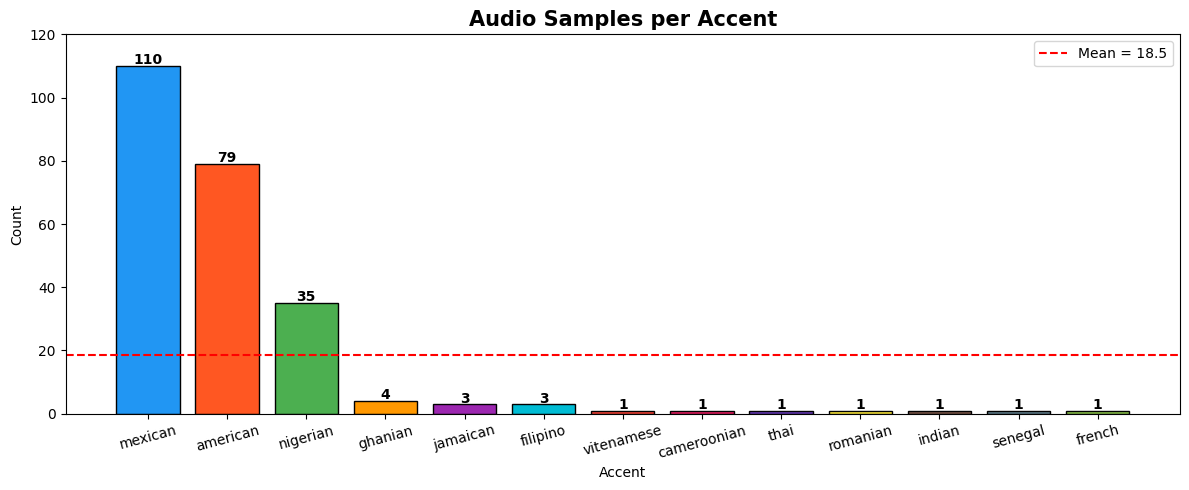


Dataset Summary:
  mexican        : 110 samples (45.6%)
  american       :  79 samples (32.8%)
  nigerian       :  35 samples (14.5%)
  ghanian        :   4 samples (1.7%)
  jamaican       :   3 samples (1.2%)
  filipino       :   3 samples (1.2%)
  vitenamese     :   1 samples (0.4%)
  cameroonian    :   1 samples (0.4%)
  thai           :   1 samples (0.4%)
  romanian       :   1 samples (0.4%)
  indian         :   1 samples (0.4%)
  senegal        :   1 samples (0.4%)
  french         :   1 samples (0.4%)

  Total : 241
  Mean  : 18.5 per accent


In [3]:
# ============================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS
# ============================================================
accent_counts = Counter(ex["accent"] for ex in examples.values())
accents_sorted, counts_sorted = zip(
    *sorted(accent_counts.items(), key=lambda x: -x[1])
)

colors = ['#2196F3','#FF5722','#4CAF50','#FF9800','#9C27B0','#00BCD4',
          '#F44336','#E91E63','#673AB7','#FFEB3B','#795548','#607D8B','#8BC34A']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(accents_sorted, counts_sorted,
              color=colors[:len(accents_sorted)], edgecolor='black')
for bar, cnt in zip(bars, counts_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha='center', fontsize=10, fontweight='bold')
ax.axhline(np.mean(counts_sorted), color='red', linestyle='--',
           label=f'Mean = {np.mean(counts_sorted):.1f}')
ax.set_title('Audio Samples per Accent', fontsize=15, fontweight='bold')
ax.set_xlabel('Accent'); ax.set_ylabel('Count')
ax.set_ylim(0, max(counts_sorted) + 10)
ax.legend(); plt.xticks(rotation=15); plt.tight_layout()
plt.savefig('accent_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDataset Summary:")
for a, c in zip(accents_sorted, counts_sorted):
    pct = c / sum(counts_sorted) * 100
    print(f"  {a:<15}: {c:>3} samples ({pct:.1f}%)")
print(f"\n  Total : {sum(counts_sorted)}")
print(f"  Mean  : {np.mean(counts_sorted):.1f} per accent")


In [4]:
# ============================================================
# SECTION 4: FEATURE EXTRACTION
# ============================================================

def segment_audio(audio_path, sr=16000, top_db=20, min_duration=0.1):
    y, sr = librosa.load(audio_path, sr=sr)
    intervals = librosa.effects.split(y, top_db=top_db)
    segments = []
    for start, end in intervals:
        duration = (end - start) / sr
        if duration >= min_duration:
            segments.append({
                'start': start / sr, 'end': end / sr,
                'duration': duration, 'audio': y[start:end], 'sr': sr
            })
    return segments, y, sr


def extract_formants(audio_path):
    snd     = parselmouth.Sound(audio_path)
    formant = snd.to_formant_burg()
    mid     = snd.duration / 2.0
    return formant.get_value_at_time(1, mid), formant.get_value_at_time(2, mid)


def extract_spectral_features(file_path, sr=16000):
    y, sr = librosa.load(file_path, sr=sr)
    feats = {}
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    feats['mfcc'] = np.mean(mfcc, axis=1)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    feats['mel_spec'] = np.mean(librosa.amplitude_to_db(mel, ref=np.max), axis=1)
    feats['spectral_centroid'] = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    feats['spectral_rolloff']  = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))
    feats['spectral_contrast'] = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1)
    feats['chroma']   = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    feats['tonnetz']  = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr), axis=1)
    feats['zcr'] = float(np.mean(librosa.feature.zero_crossing_rate(y)))
    feats['rms'] = float(np.mean(librosa.feature.rms(y=y)))
    snd   = parselmouth.Sound(file_path)
    pitch = snd.to_pitch()
    f0    = pitch.selected_array['frequency']
    f0    = f0[f0 != 0]
    feats['f0_mean'] = float(np.mean(f0)) if len(f0) > 0 else 0.0
    feats['f0_std']  = float(np.std(f0))  if len(f0) > 0 else 0.0
    return feats


def extract_consonant_features(file_path, sr=16000):
    y, sr  = librosa.load(file_path, sr=sr)
    feats  = {}
    stft   = np.abs(librosa.stft(y))
    freqs  = librosa.fft_frequencies(sr=sr)
    th_mask   = (freqs >= 6000) & (freqs <= 8000)
    feats['th_energy'] = float(np.mean(stft[th_mask, :]))
    fric_mask = (freqs >= 3000) & (freqs <= 8000)
    feats['fricative_energy'] = float(np.mean(stft[fric_mask, :]) / (np.mean(stft) + 1e-8))
    rms   = librosa.feature.rms(y=y)[0]
    diff  = np.diff(rms)
    thresh = np.mean(diff) + 2 * np.std(diff)
    feats['stop_rate'] = float(np.sum(diff > thresh) / (len(y) / sr))
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    feats['vot_ratio'] = float(np.mean((zcr > np.mean(zcr)) & (rms < np.mean(rms))))
    low_e = rms < np.mean(rms) * 0.3
    clusters, count = [], 0
    for v in low_e:
        if v: count += 1
        elif count > 0: clusters.append(count); count = 0
    feats['cluster_mean'] = float(np.mean(clusters)) if clusters else 0.0
    feats['cluster_max']  = float(np.max(clusters))  if clusters else 0.0
    intervals = librosa.effects.split(y, top_db=20)
    durs = [(e - s) / sr for s, e in intervals]
    feats['vowel_dur_mean'] = float(np.mean(durs)) if durs else 0.0
    feats['vowel_dur_std']  = float(np.std(durs))  if durs else 0.0
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    feats['speech_rate'] = float(np.squeeze(tempo))
    return feats


def flatten_features(feat_dict):
    vec = []
    for v in feat_dict.values():
        if isinstance(v, np.ndarray): vec.extend(v.tolist())
        else: vec.append(float(v))
    return np.array(vec)


def get_feature_names():
    names  = [f'mfcc_{i}'     for i in range(13)]
    names += [f'mel_{i}'      for i in range(64)]
    names += ['spectral_centroid', 'spectral_rolloff']
    names += [f'contrast_{i}' for i in range(7)]
    names += [f'chroma_{i}'   for i in range(12)]
    names += [f'tonnetz_{i}'  for i in range(6)]
    names += ['zcr', 'rms', 'f0_mean', 'f0_std']
    names += ['th_energy', 'fricative_energy', 'stop_rate', 'vot_ratio',
              'cluster_mean', 'cluster_max', 'vowel_dur_mean',
              'vowel_dur_std', 'speech_rate']
    return names


print("Extracting features (this may take a few minutes)...")
all_features, all_labels, formant_data = [], [], []

for key, ex in examples.items():
    path   = ex["file_path"]
    accent = ex["accent"]
    spec_feats = extract_spectral_features(path)
    cons_feats = extract_consonant_features(path)
    combined   = {**spec_feats, **cons_feats}
    all_features.append(flatten_features(combined))
    all_labels.append(accent)
    f1, f2 = extract_formants(path)
    if f1 and f2:
        formant_data.append({"accent": accent, "f1": f1, "f2": f2})

X             = np.array(all_features)
y_labels      = np.array(all_labels)
feature_names = get_feature_names()
print(f"Feature matrix shape: {X.shape}")


Extracting features (this may take a few minutes)...
Feature matrix shape: (241, 117)



Top 15 Most Discriminative Features (ANOVA):
   feature   F_stat      p_value
    mel_29 9.488809 7.212610e-15
contrast_6 9.123118 2.767150e-14
    mel_28 9.109807 2.906636e-14
     mel_5 8.717278 1.248489e-13
    mel_27 8.569903 2.165875e-13
    mfcc_0 8.551377 2.321499e-13
    mel_33 8.523621 2.575992e-13
    mel_34 8.500545 2.808840e-13
    mel_30 8.259448 6.957223e-13
    mel_26 8.244101 7.372055e-13
    mel_15 8.142355 1.082848e-12
    mel_32 8.106459 1.240433e-12
     mel_4 7.987523 1.947324e-12
contrast_0 7.714881 5.501407e-12
    mel_31 7.659989 6.786130e-12


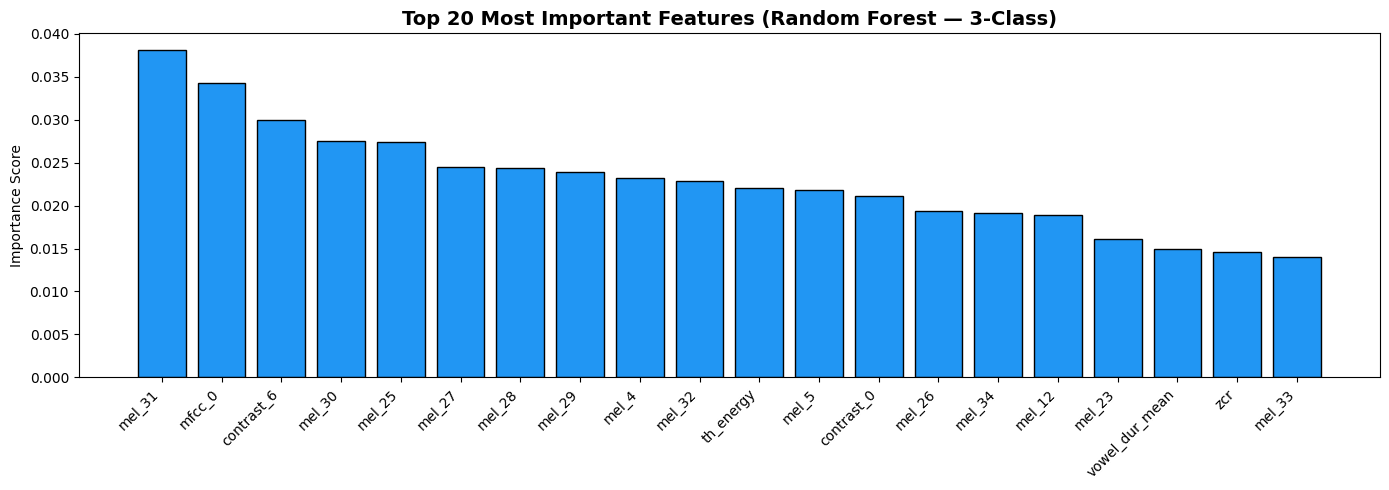


Top 5 features for 3-class problem:
  1. mel_31: 0.0381
  2. mfcc_0: 0.0343
  3. contrast_6: 0.0300
  4. mel_30: 0.0275
  5. mel_25: 0.0274


In [5]:
# ============================================================
# SECTION 5A: FEATURE IMPORTANCE ANALYSIS
# ============================================================

# ---- ANOVA across all accents ----
print("\nTop 15 Most Discriminative Features (ANOVA):")
df_feat = pd.DataFrame(X, columns=feature_names)
df_feat['accent'] = y_labels
anova_results = []
for col in feature_names:
    groups  = [df_feat[df_feat['accent'] == a][col].values
                for a in df_feat['accent'].unique()]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append((col, f_stat, p_val))
anova_df = (pd.DataFrame(anova_results, columns=['feature','F_stat','p_value'])
              .sort_values('F_stat', ascending=False))
print(anova_df.head(15).to_string(index=False))

# ---- Random Forest on 3-class filtered data ----
# NEW: only use the 3 main classes for importance
THREE_CLASSES = ['mexican', 'american', 'nigerian']
three_mask    = np.array([a in THREE_CLASSES for a in y_labels])
X_3           = X[three_mask]
y_3_labels    = y_labels[three_mask]

le        = LabelEncoder()
y_3_enc   = le.fit_transform(y_3_labels)

X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X_3, y_3_enc, test_size=0.25, random_state=42, stratify=y_3_enc)

scaler   = StandardScaler()
X3_tr_sc = scaler.fit_transform(X3_tr)
X3_te_sc = scaler.transform(X3_te)

rf          = RandomForestClassifier(n_estimators=200, random_state=42,
                                      class_weight='balanced')
rf.fit(X3_tr_sc, y3_tr)
importances = rf.feature_importances_
top_idx     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(14, 5))
plt.bar(range(20), importances[top_idx], color='#2196F3', edgecolor='black')
plt.xticks(range(20), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 Most Important Features (Random Forest — 3-Class)',
          fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_3class.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTop 5 features for 3-class problem:")
for i, idx in enumerate(top_idx[:5]):
    print(f"  {i+1}. {feature_names[idx]}: {importances[idx]:.4f}")


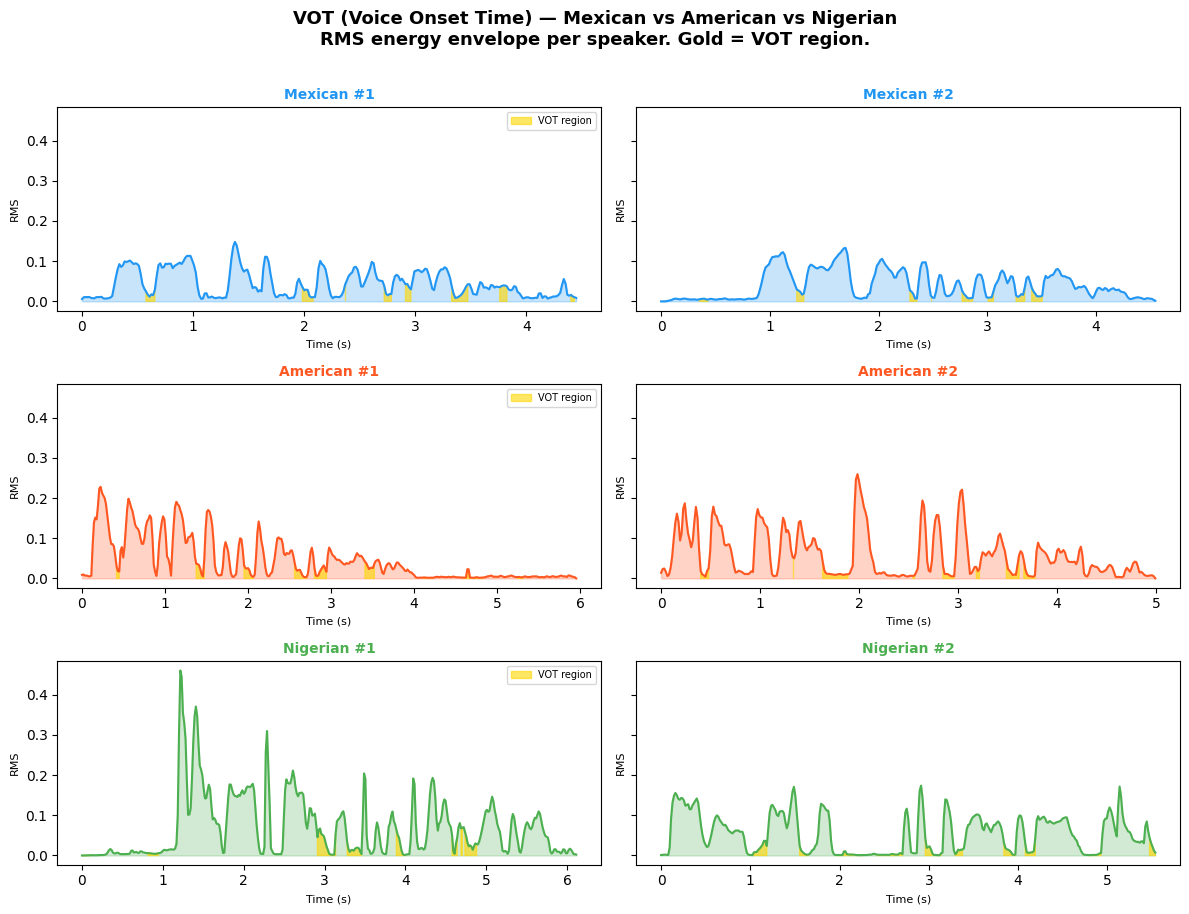

Saved: vot_waveform_comparison_3class.png


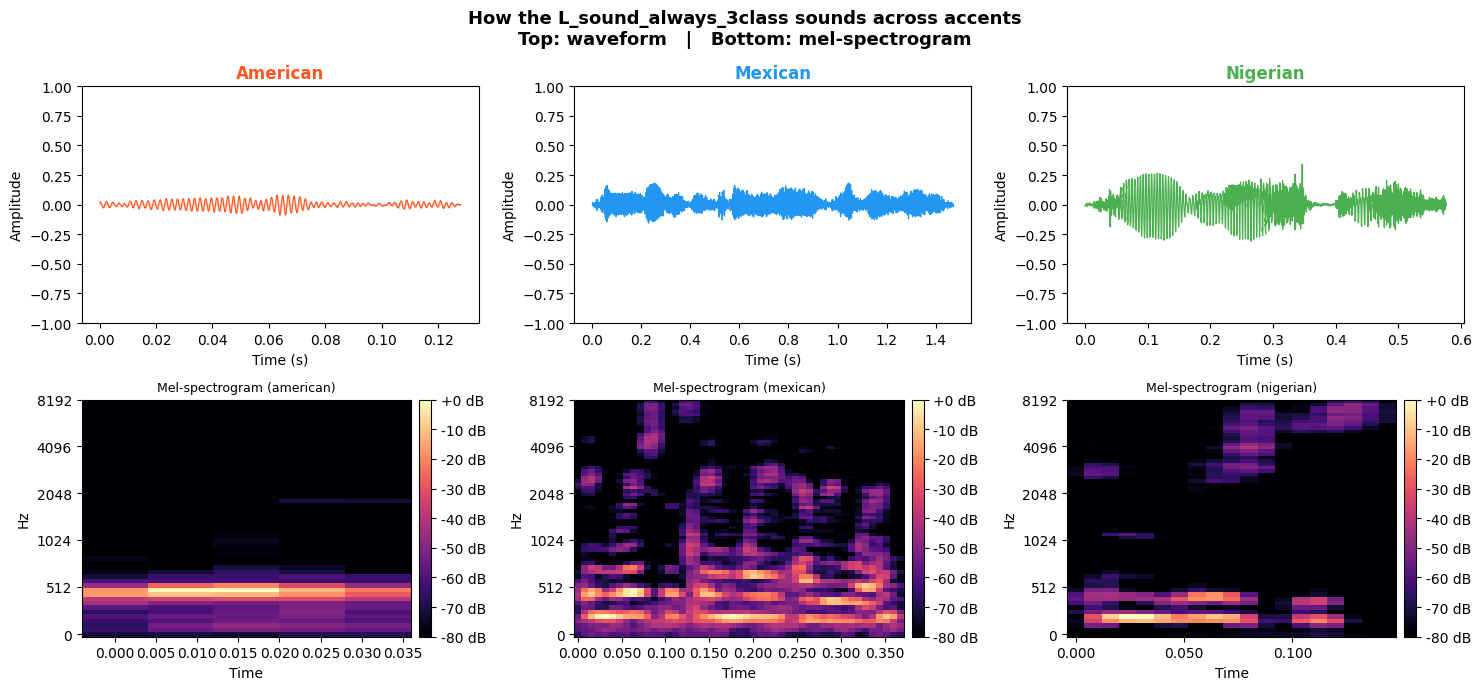

Saved: sound_comparison_L_sound_always_3class.png


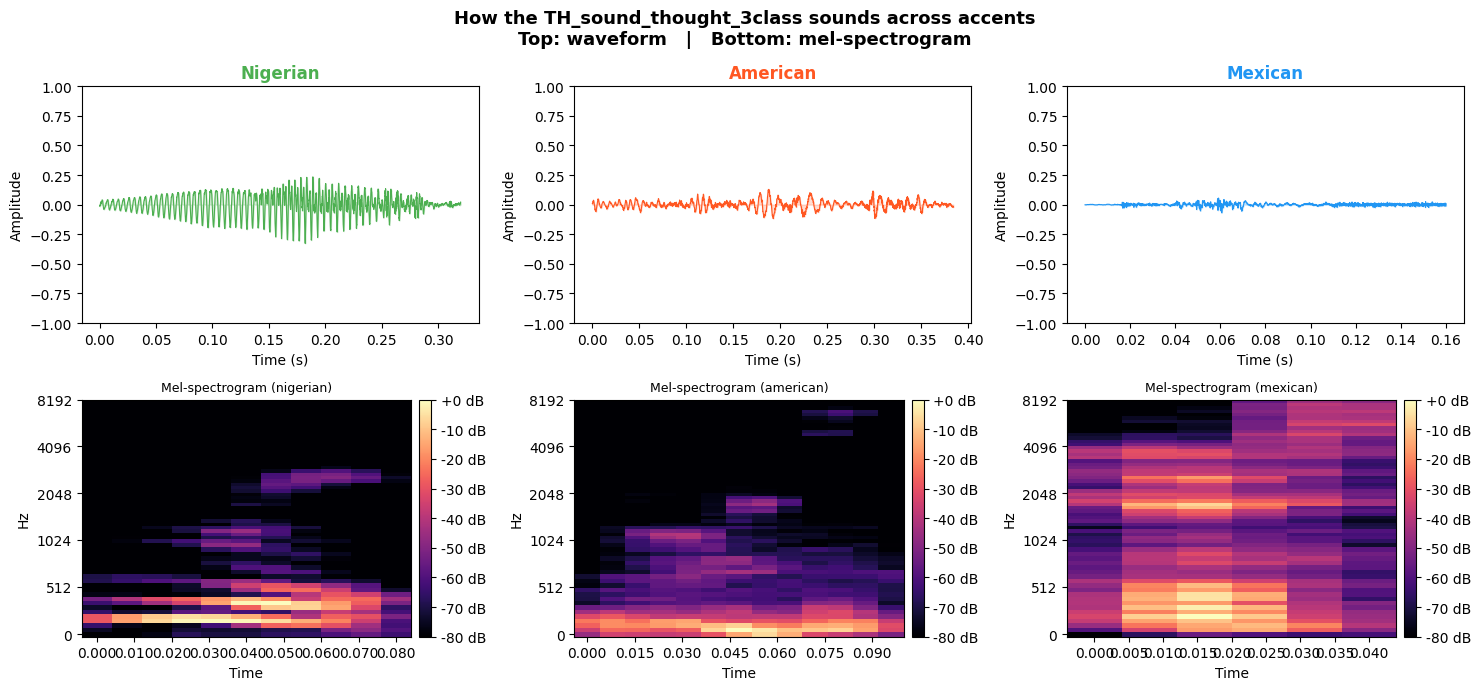

Saved: sound_comparison_TH_sound_thought_3class.png


In [6]:
# ============================================================
# SECTION 5B: SPEECH PLOTS FOR TOP FEATURES
# ============================================================

# ---- PLOT 1: VOT waveforms — now showing all 3 accents ----
def plot_vot_comparison_3class(examples, n_per_accent=2):
    """
    Shows RMS energy envelopes for Mexican, American, and Nigerian.
    Now uses 3 rows instead of 2.
    """
    fig, axes = plt.subplots(3, n_per_accent, figsize=(12, 9), sharey=True)
    fig.suptitle(
        'VOT (Voice Onset Time) — Mexican vs American vs Nigerian\n'
        'RMS energy envelope per speaker. Gold = VOT region.',
        fontsize=13, fontweight='bold', y=1.01)

    colors = {'mexican': '#2196F3', 'american': '#FF5722', 'nigerian': '#4CAF50'}
    count  = {'mexican': 0, 'american': 0, 'nigerian': 0}
    rows   = {'mexican': 0, 'american': 1, 'nigerian': 2}

    for key, ex in examples.items():
        acc = ex['accent']
        if acc not in colors or count[acc] >= n_per_accent:
            continue
        y_audio, sr = librosa.load(ex['file_path'], sr=16000)
        rms   = librosa.feature.rms(y=y_audio, frame_length=512, hop_length=256)[0]
        times = librosa.times_like(rms, sr=sr, hop_length=256)
        zcr   = librosa.feature.zero_crossing_rate(y_audio, hop_length=256)[0]
        ml    = min(len(rms), len(zcr))
        vot_mask = (zcr[:ml] > np.mean(zcr)) & (rms[:ml] < np.mean(rms))

        ax = axes[rows[acc]][count[acc]]
        ax.plot(times, rms, color=colors[acc], linewidth=1.5)
        ax.fill_between(times, rms, alpha=0.25, color=colors[acc])
        ax.fill_between(times[:ml], rms[:ml], where=vot_mask,
                        color='gold', alpha=0.6, label='VOT region')
        ax.set_xlabel('Time (s)', fontsize=8)
        ax.set_ylabel('RMS', fontsize=8)
        ax.set_title(f'{acc.capitalize()} #{count[acc]+1}',
                     fontsize=10, color=colors[acc], fontweight='bold')
        if count[acc] == 0:
            ax.legend(fontsize=7, loc='upper right')
        count[acc] += 1

    plt.tight_layout()
    plt.savefig('vot_waveform_comparison_3class.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: vot_waveform_comparison_3class.png")

plot_vot_comparison_3class(examples)


# ---- PLOT 2: Sound comparison — now all 3 accents ----
def plot_sound_across_accents_3class(examples, seg_index, seg_label):
    """
    Waveform + mel-spectrogram for the same word segment
    from Mexican, American, and Nigerian speakers.
    """
    accents_to_plot = ['mexican', 'american', 'nigerian']
    color_map_acc   = {'mexican': '#2196F3', 'american': '#FF5722',
                       'nigerian': '#4CAF50'}
    collected = {}

    for key, ex in examples.items():
        acc = ex['accent']
        if acc not in accents_to_plot or acc in collected:
            continue
        segs, _, sr = segment_audio(ex['file_path'])
        if seg_index < len(segs):
            collected[acc] = {'audio': segs[seg_index]['audio'],
                              'sr': sr, 'key': key}
        if len(collected) == len(accents_to_plot):
            break

    if not collected:
        print(f"No segments found for index {seg_index}.")
        return

    n   = len(collected)
    fig = plt.figure(figsize=(5 * n, 7))
    fig.suptitle(
        f'How the {seg_label} sounds across accents\n'
        f'Top: waveform   |   Bottom: mel-spectrogram',
        fontsize=13, fontweight='bold')

    for col, (acc, data) in enumerate(collected.items()):
        y_audio = data['audio']
        sr_     = data['sr']
        t       = np.linspace(0, len(y_audio) / sr_, len(y_audio))
        color   = color_map_acc.get(acc, 'gray')

        ax_w = fig.add_subplot(2, n, col + 1)
        ax_w.plot(t, y_audio, color=color, linewidth=0.8)
        ax_w.fill_between(t, y_audio, alpha=0.2, color=color)
        ax_w.set_title(f'{acc.capitalize()}', fontsize=12,
                       fontweight='bold', color=color)
        ax_w.set_xlabel('Time (s)'); ax_w.set_ylabel('Amplitude')
        ax_w.set_ylim(-1, 1)

        ax_s = fig.add_subplot(2, n, n + col + 1)
        mel    = librosa.feature.melspectrogram(y=y_audio, sr=sr_,
                                                n_mels=64, fmax=8000)
        mel_db = librosa.amplitude_to_db(mel, ref=np.max)
        img = librosa.display.specshow(mel_db, sr=sr_, hop_length=128,
                                       x_axis='time', y_axis='mel',
                                       fmax=8000, ax=ax_s, cmap='magma')
        ax_s.set_title(f'Mel-spectrogram ({acc})', fontsize=9)
        fig.colorbar(img, ax=ax_s, format='%+2.0f dB', pad=0.02)

    plt.tight_layout()
    safe_label = seg_label.replace(' ', '_').replace('/', '_').replace("'", '')
    fname = f'sound_comparison_{safe_label}.png'
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

plot_sound_across_accents_3class(examples, seg_index=6,
                                  seg_label="L_sound_always_3class")
plot_sound_across_accents_3class(examples, seg_index=7,
                                  seg_label="TH_sound_thought_3class")


In [7]:
# ============================================================
# SECTION 6: DEEP SPEECH EMBEDDINGS (ECAPA-TDNN)
# ============================================================
model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="/content/drive/MyDrive/senior_project/pretrained_model"
)

embeddings, emb_labels = [], []
for key, ex in examples.items():
    signal = model.load_audio(ex["file_path"])
    emb    = model.encode_batch(signal)
    embeddings.append(emb.squeeze().cpu().numpy())
    emb_labels.append(ex["accent"])

embeddings = np.array(embeddings)
print(f"Embeddings shape: {embeddings.shape}")




INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


hyperparams.yaml:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


...

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


label_encoder.txt:   0%|          | 0.00/129k [00:00<?, ?B/s]

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


Embeddings shape: (241, 192)


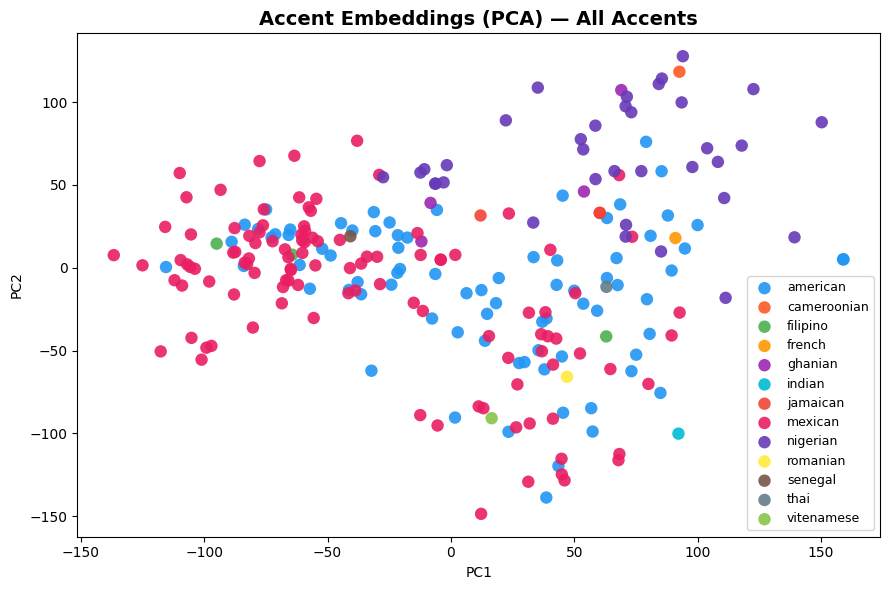

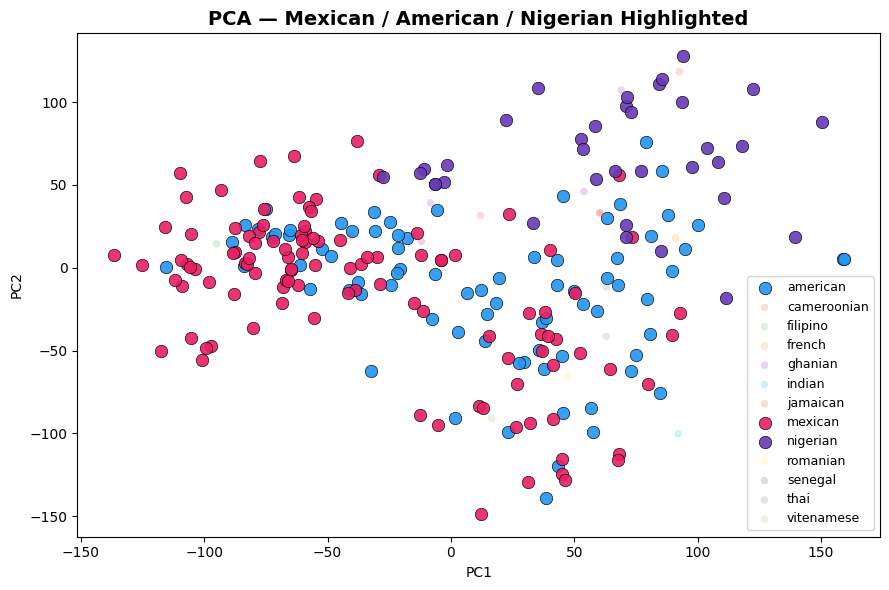

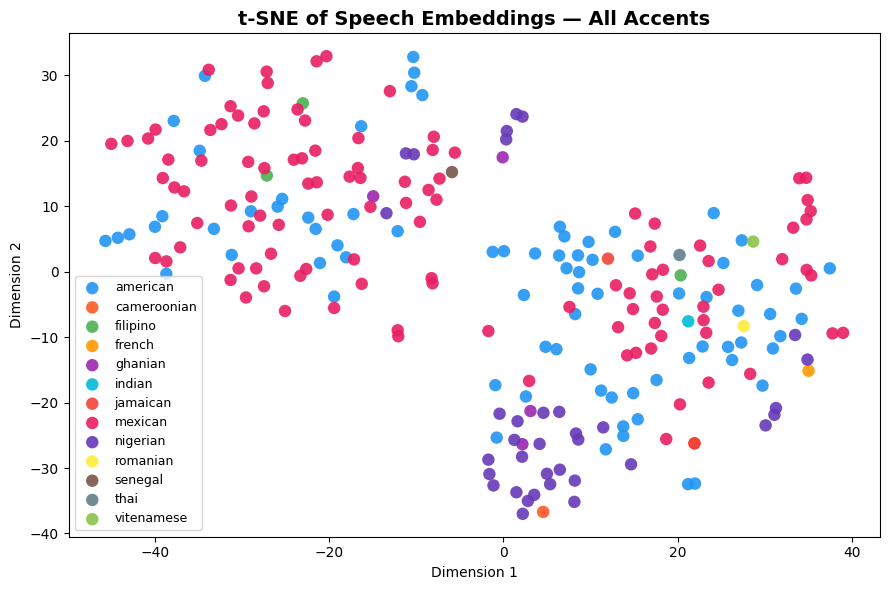

In [8]:
# ============================================================
# SECTION 7: DIMENSIONALITY REDUCTION
# ============================================================
unique_accents = sorted(set(emb_labels))
palette        = ['#2196F3','#FF5722','#4CAF50','#FF9800',
                  '#9C27B0','#00BCD4','#F44336','#E91E63',
                  '#673AB7','#FFEB3B','#795548','#607D8B','#8BC34A']
color_map      = {a: palette[i] for i, a in enumerate(unique_accents)}


def scatter_plot(coords, labels, title, xlabel, ylabel, filename,
                 highlight=None):
    plt.figure(figsize=(9, 6))
    for accent in sorted(set(labels)):
        idx = [i for i, l in enumerate(labels) if l == accent]
        alpha = 0.9 if (highlight is None or accent in highlight) else 0.2
        size  = 80  if (highlight is None or accent in highlight) else 30
        plt.scatter(coords[idx, 0], coords[idx, 1],
                    label=accent, color=color_map[accent],
                    alpha=alpha, s=size,
                    edgecolors='black' if (highlight and accent in highlight) else 'none',
                    linewidths=0.5)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


x_pca = PCA(n_components=2).fit_transform(embeddings)
scatter_plot(x_pca, emb_labels,
             "Accent Embeddings (PCA) — All Accents", "PC1", "PC2",
             "pca_plot_all.png")

# PCA highlighting only the 3 main classes
scatter_plot(x_pca, emb_labels,
             "PCA — Mexican / American / Nigerian Highlighted",
             "PC1", "PC2", "pca_3class_highlight.png",
             highlight=THREE_CLASSES)

x_tsne = TSNE(n_components=2, perplexity=10,
              learning_rate=200, random_state=42).fit_transform(embeddings)
scatter_plot(x_tsne, emb_labels,
             "t-SNE of Speech Embeddings — All Accents",
             "Dimension 1", "Dimension 2", "tsne_plot.png")

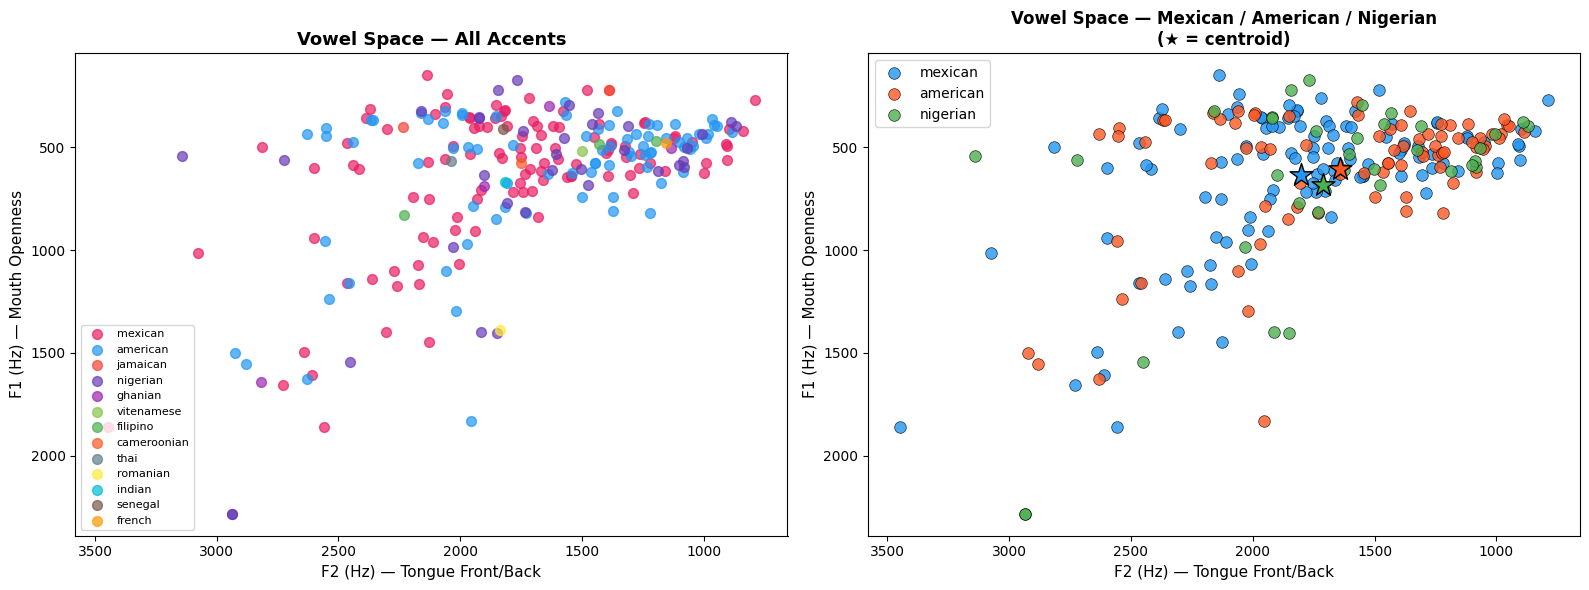


Vowel Space Observations:
  mexican     : mean F1=637 Hz, mean F2=1803 Hz (n=110)
  american    : mean F1=607 Hz, mean F2=1644 Hz (n=79)
  nigerian    : mean F1=685 Hz, mean F2=1713 Hz (n=35)


In [9]:
# ============================================================
# SECTION 8: VOWEL SPACE VISUALIZATION (F1 / F2)
# ============================================================
df_formants = pd.DataFrame(formant_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: all accents
ax = axes[0]
for accent in df_formants["accent"].unique():
    sub = df_formants[df_formants["accent"] == accent]
    ax.scatter(sub["f2"], sub["f1"], label=accent,
               color=color_map.get(accent, 'gray'), alpha=0.7, s=50)
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel("F2 (Hz) — Tongue Front/Back", fontsize=11)
ax.set_ylabel("F1 (Hz) — Mouth Openness",    fontsize=11)
ax.set_title("Vowel Space — All Accents", fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=8)

# Right: 3 main classes only with confidence ellipses
ax2 = axes[1]
color_3 = {'mexican': '#2196F3', 'american': '#FF5722', 'nigerian': '#4CAF50'}
df_3 = df_formants[df_formants['accent'].isin(THREE_CLASSES)]
for accent in THREE_CLASSES:
    sub = df_3[df_3["accent"] == accent]
    ax2.scatter(sub["f2"], sub["f1"], label=accent,
                color=color_3[accent], alpha=0.8, s=70, edgecolors='black',
                linewidths=0.5)
    # Draw centroid marker
    ax2.scatter(sub["f2"].mean(), sub["f1"].mean(),
                color=color_3[accent], marker='*', s=300,
                edgecolors='black', linewidths=1, zorder=5)
ax2.invert_xaxis(); ax2.invert_yaxis()
ax2.set_xlabel("F2 (Hz) — Tongue Front/Back", fontsize=11)
ax2.set_ylabel("F1 (Hz) — Mouth Openness",    fontsize=11)
ax2.set_title("Vowel Space — Mexican / American / Nigerian\n(★ = centroid)",
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('vowel_space_3class.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVowel Space Observations:")
for acc in THREE_CLASSES:
    sub = df_3[df_3['accent'] == acc]
    print(f"  {acc:<12}: mean F1={sub['f1'].mean():.0f} Hz, "
          f"mean F2={sub['f2'].mean():.0f} Hz (n={len(sub)})")

SECTION 9: 3-CLASS ANALYSIS
Mexican vs American vs Nigerian

  Mexican  : 110 samples
  American : 79 samples
  Nigerian : 35 samples
  Total    : 224
  Chance   : 33.3%
  Train/test split: 75/25 stratified

Logistic Regression (ECAPA) — Accuracy: 82.1%
              precision    recall  f1-score   support

    american       0.81      0.65      0.72        20
     mexican       0.80      0.89      0.84        27
    nigerian       0.90      1.00      0.95         9

    accuracy                           0.82        56
   macro avg       0.84      0.85      0.84        56
weighted avg       0.82      0.82      0.82        56

SVM (hand-crafted) — Accuracy: 78.6%
              precision    recall  f1-score   support

    american       0.74      0.70      0.72        20
     mexican       0.81      0.78      0.79        27
    nigerian       0.82      1.00      0.90         9

    accuracy                           0.79        56
   macro avg       0.79      0.83      0.80        56
we

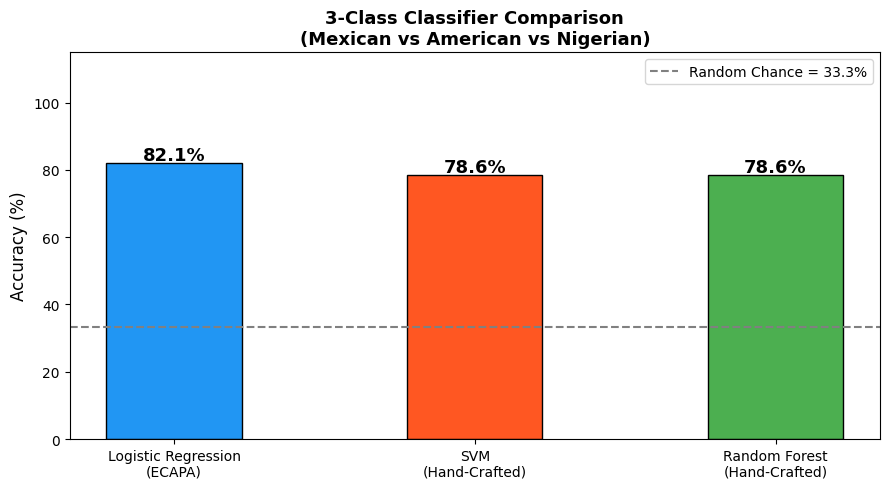

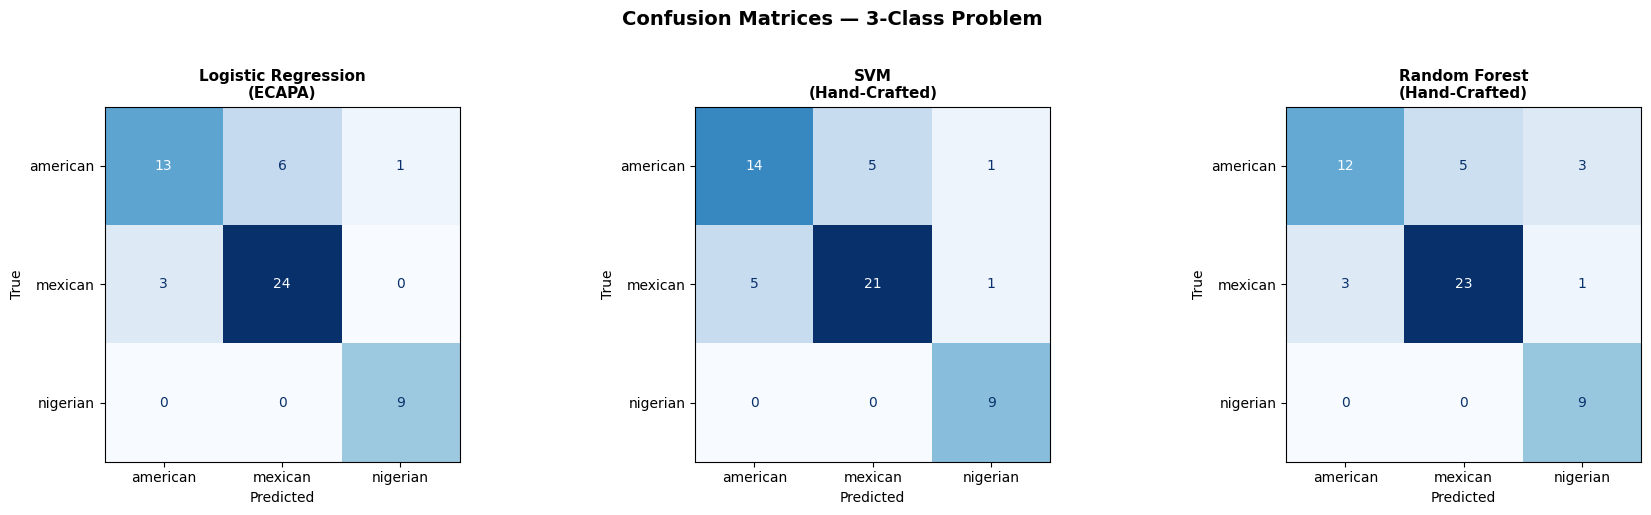

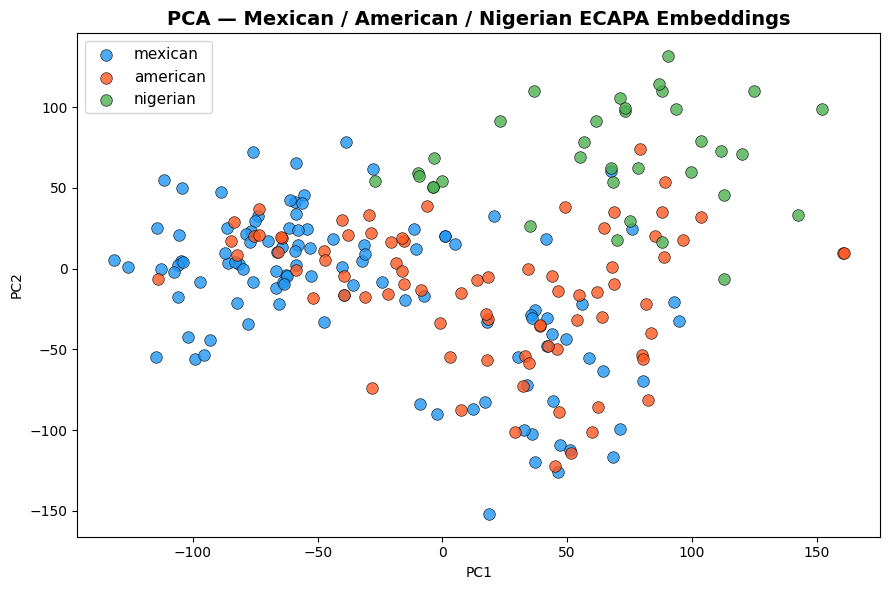


3-CLASS RESULTS SUMMARY
  Logistic Regression (ECAPA) : 82.1%
  SVM (hand-crafted)          : 78.6%
  Random Forest               : 78.6%
  Chance level                : 33.3%


In [10]:
# ============================================================
# SECTION 9: 3-CLASS ANALYSIS — Mexican vs American vs Nigerian
# ============================================================
# This is now the MAIN classification task.
# Chance level = 33.3%
# ============================================================

print("=" * 60)
print("SECTION 9: 3-CLASS ANALYSIS")
print("Mexican vs American vs Nigerian")
print("=" * 60)

print(f"\n  Mexican  : {np.sum(y_3_labels=='mexican')} samples")
print(f"  American : {np.sum(y_3_labels=='american')} samples")
print(f"  Nigerian : {np.sum(y_3_labels=='nigerian')} samples")
print(f"  Total    : {len(y_3_labels)}")
print(f"  Chance   : 33.3%")
print(f"  Train/test split: 75/25 stratified")

# Filter embeddings to 3 classes
emb_3_mask   = np.array([a in THREE_CLASSES for a in emb_labels])
emb_3        = embeddings[emb_3_mask]
emb_3_labels = np.array(emb_labels)[emb_3_mask]

le3          = LabelEncoder()
y_3_enc_full = le3.fit_transform(y_3_labels)
emb_3_enc    = le3.transform(emb_3_labels)

# Use the X3 split already created in Section 5A
# (X3_tr_sc, X3_te_sc, y3_tr, y3_te)

# Embeddings split
Xe3_tr, Xe3_te, ye3_tr, ye3_te = train_test_split(
    emb_3, emb_3_enc, test_size=0.25,
    random_state=42, stratify=emb_3_enc)

# ---- 9a. Logistic Regression on ECAPA embeddings ----
lr3       = LogisticRegression(max_iter=3000, class_weight='balanced')
lr3.fit(Xe3_tr, ye3_tr)
lr3_pred  = lr3.predict(Xe3_te)
lr3_acc   = accuracy_score(ye3_te, lr3_pred)

print(f"\nLogistic Regression (ECAPA) — Accuracy: {lr3_acc*100:.1f}%")
print(classification_report(ye3_te, lr3_pred,
                             target_names=le3.classes_,
                             zero_division=0))

# ---- 9b. SVM on hand-crafted features ----
svm3      = SVC(kernel='rbf', C=5.0, gamma='scale',
                random_state=42, class_weight='balanced',
                probability=True)
svm3.fit(X3_tr_sc, y3_tr)
svm3_pred = svm3.predict(X3_te_sc)
svm3_acc  = accuracy_score(y3_te, svm3_pred)

print(f"SVM (hand-crafted) — Accuracy: {svm3_acc*100:.1f}%")
print(classification_report(y3_te, svm3_pred,
                             target_names=le3.classes_,
                             zero_division=0))

# ---- 9c. Random Forest (already trained in 5A, re-evaluate) ----
rf3_pred  = rf.predict(X3_te_sc)
rf3_acc   = accuracy_score(y3_te, rf3_pred)
print(f"Random Forest     — Accuracy: {rf3_acc*100:.1f}%")

# ---- 9d. Cross-validation scores (more robust with small dataset) ----
print("\n5-Fold Cross-Validation (on full 3-class set):")
scaler_cv   = StandardScaler()
X_3_sc_full = scaler_cv.fit_transform(X_3)
for name, clf in [
    ("LR (hand-crafted)",   LogisticRegression(max_iter=3000, class_weight='balanced')),
    ("SVM (hand-crafted)",  SVC(kernel='rbf', C=5.0, gamma='scale', class_weight='balanced')),
    ("RF  (hand-crafted)",  RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
]:
    scores = cross_val_score(clf, X_3_sc_full, y_3_enc_full,
                              cv=5, scoring='accuracy')
    print(f"  {name:<25}: {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")

# ---- 9e. Comparison bar chart ----
fig, ax = plt.subplots(figsize=(9, 5))
model_names = ['Logistic Regression\n(ECAPA)', 'SVM\n(Hand-Crafted)', 'Random Forest\n(Hand-Crafted)']
accs3       = [lr3_acc, svm3_acc, rf3_acc]
bar_colors  = ['#2196F3', '#FF5722', '#4CAF50']
bars        = ax.bar(model_names, [a*100 for a in accs3],
                     color=bar_colors, edgecolor='black', width=0.45)
for bar, acc in zip(bars, accs3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{acc*100:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.axhline(33.3, color='gray', linestyle='--', linewidth=1.5,
           label='Random Chance = 33.3%')
ax.set_ylim(0, 115); ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('3-Class Classifier Comparison\n(Mexican vs American vs Nigerian)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout()
plt.savefig('classifier_comparison_3class.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- 9f. Confusion matrices — all 3 models ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_, name, true, pred in [
    (axes[0], "Logistic Regression\n(ECAPA)",        ye3_te,  lr3_pred),
    (axes[1], "SVM\n(Hand-Crafted)",                 y3_te,   svm3_pred),
    (axes[2], "Random Forest\n(Hand-Crafted)",       y3_te,   rf3_pred),
]:
    ConfusionMatrixDisplay.from_predictions(
        true, pred, display_labels=le3.classes_,
        cmap='Blues', ax=ax_, colorbar=False)
    ax_.set_title(name, fontsize=11, fontweight='bold')
    ax_.set_xlabel('Predicted'); ax_.set_ylabel('True')
plt.suptitle('Confusion Matrices — 3-Class Problem',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_3class.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- 9g. PCA of embeddings for 3 classes only ----
emb_3_only  = emb_3
lab_3_only  = emb_3_labels
x_pca_3     = PCA(n_components=2).fit_transform(emb_3_only)

plt.figure(figsize=(9, 6))
for acc in THREE_CLASSES:
    idx = [i for i, l in enumerate(lab_3_only) if l == acc]
    plt.scatter(x_pca_3[idx, 0], x_pca_3[idx, 1],
                label=acc, color=color_3[acc], alpha=0.8, s=70,
                edgecolors='black', linewidths=0.5)
plt.title('PCA — Mexican / American / Nigerian ECAPA Embeddings',
          fontsize=14, fontweight='bold')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(fontsize=11); plt.tight_layout()
plt.savefig('pca_3class.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n3-CLASS RESULTS SUMMARY")
print(f"  Logistic Regression (ECAPA) : {lr3_acc*100:.1f}%")
print(f"  SVM (hand-crafted)          : {svm3_acc*100:.1f}%")
print(f"  Random Forest               : {rf3_acc*100:.1f}%")
print(f"  Chance level                : 33.3%")


SECTION 10: PAIRWISE ANALYSIS
Understanding which accent pairs are easy vs hard
  mexican    vs american  : 80.4% ± 7.1%  (chance 50%)
  mexican    vs nigerian  : 96.6% ± 2.2%  (chance 50%)
  american   vs nigerian  : 89.5% ± 2.1%  (chance 50%)


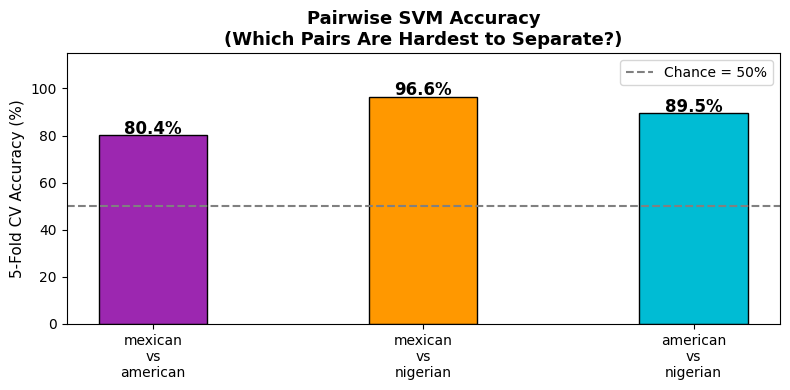


Interpretation:
  Easiest pair: mexican vs nigerian (96.6%)
  Hardest pair: mexican vs american (80.4%)
  The hardest pair tells us where the model needs the most help.

Key Feature Means — 3 Accents:
            mfcc_0  contrast_6    mel_1  th_energy  vowel_dur_mean  vot_ratio   f0_mean  spectral_centroid     rms  fricative_energy
accent                                                                                                                              
american -296.0529     27.0805 -59.9019     0.0480          1.6994     0.1748  176.1350          1452.4683  0.0545            0.2432
mexican  -215.7983     32.2442 -50.6096     0.1174          2.1803     0.1886  159.0120          1549.1265  0.0769            0.2748
nigerian -298.3633     28.6952 -71.8339     0.0765          0.6952     0.2439  183.6821          1606.7364  0.0684            0.2862


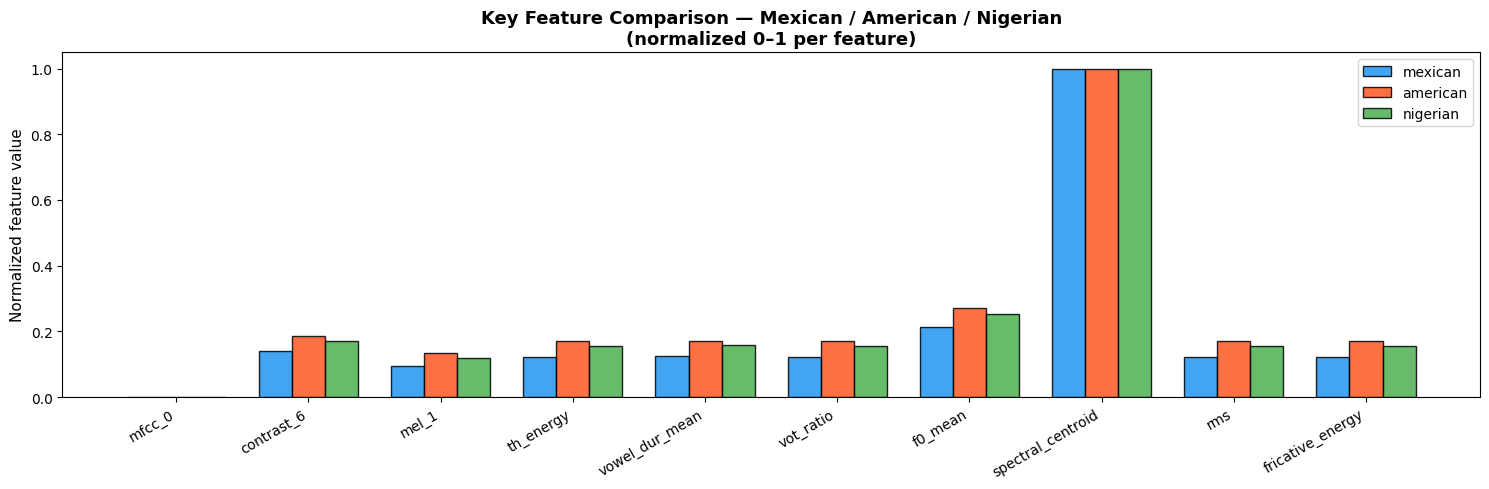

Saved: feature_comparison_3accents.png


In [11]:
# ============================================================
# SECTION 10: PAIRWISE ANALYSIS
# What makes each pair easy or hard to separate?
# This is NEW and important now that we have 3 classes.
# ============================================================

print("\n" + "=" * 60)
print("SECTION 10: PAIRWISE ANALYSIS")
print("Understanding which accent pairs are easy vs hard")
print("=" * 60)

pairs = [
    ('mexican',  'american'),
    ('mexican',  'nigerian'),
    ('american', 'nigerian'),
]

pair_results = {}
for acc1, acc2 in pairs:
    mask = np.array([a in [acc1, acc2] for a in y_3_labels])
    X_pair = X_3[mask]
    y_pair = y_3_labels[mask]

    le_pair   = LabelEncoder()
    y_enc_pair = le_pair.fit_transform(y_pair)

    sc_pair = StandardScaler()
    X_sc    = sc_pair.fit_transform(X_pair)

    svm_pair = SVC(kernel='rbf', C=5.0, gamma='scale',
                   class_weight='balanced', random_state=42)
    scores   = cross_val_score(svm_pair, X_sc, y_enc_pair,
                                cv=5, scoring='accuracy')
    pair_results[(acc1, acc2)] = scores.mean()
    print(f"  {acc1:<10} vs {acc2:<10}: "
          f"{scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%  "
          f"(chance 50%)")

# Visual summary of pairwise difficulty
fig, ax = plt.subplots(figsize=(8, 4))
pair_labels = [f"{a}\nvs\n{b}" for a, b in pairs]
pair_accs   = [pair_results[p]*100 for p in pairs]
bar_c = ['#9C27B0', '#FF9800', '#00BCD4']
bars  = ax.bar(pair_labels, pair_accs, color=bar_c, edgecolor='black', width=0.4)
for bar, acc in zip(bars, pair_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.axhline(50, color='gray', linestyle='--', label='Chance = 50%')
ax.set_ylim(0, 115); ax.set_ylabel('5-Fold CV Accuracy (%)', fontsize=11)
ax.set_title('Pairwise SVM Accuracy\n(Which Pairs Are Hardest to Separate?)',
             fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('pairwise_difficulty.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
best_pair  = max(pair_results, key=pair_results.get)
worst_pair = min(pair_results, key=pair_results.get)
print(f"  Easiest pair: {best_pair[0]} vs {best_pair[1]} "
      f"({pair_results[best_pair]*100:.1f}%)")
print(f"  Hardest pair: {worst_pair[0]} vs {worst_pair[1]} "
      f"({pair_results[worst_pair]*100:.1f}%)")
print("  The hardest pair tells us where the model needs the most help.")


# ============================================================
# SECTION 10B: FEATURE COMPARISON ACROSS 3 ACCENTS
# Which features best separate each pair?
# ============================================================

KEY_FEATURES_3 = ['mfcc_0', 'contrast_6', 'mel_1', 'th_energy',
                   'vowel_dur_mean', 'vot_ratio', 'f0_mean',
                   'spectral_centroid', 'rms', 'fricative_energy']

df_3feat = pd.DataFrame(X_3, columns=feature_names)
df_3feat['accent'] = y_3_labels

means_3 = df_3feat.groupby('accent')[KEY_FEATURES_3].mean()

print("\nKey Feature Means — 3 Accents:")
print(means_3.round(4).to_string())

# Radar-style bar comparison for top features
n_feats = len(KEY_FEATURES_3)
x       = np.arange(n_feats)
w       = 0.25
fig, ax = plt.subplots(figsize=(15, 5))

for i, acc in enumerate(THREE_CLASSES):
    vals = means_3.loc[acc, KEY_FEATURES_3].values
    # normalize per feature for visual comparison
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-8)
    ax.bar(x + i*w, norm, w, label=acc, color=color_3[acc],
           edgecolor='black', alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(KEY_FEATURES_3, rotation=30, ha='right')
ax.set_ylabel('Normalized feature value', fontsize=11)
ax.set_title('Key Feature Comparison — Mexican / American / Nigerian\n'
             '(normalized 0–1 per feature)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout()
plt.savefig('feature_comparison_3accents.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: feature_comparison_3accents.png")



Key Feature Means — 3 Accents:
            mfcc_0  contrast_6    mel_1  th_energy  vowel_dur_mean  vot_ratio   f0_mean  spectral_centroid     rms  fricative_energy
accent                                                                                                                              
american -296.0529     27.0805 -59.9019     0.0480          1.6994     0.1748  176.1350          1452.4683  0.0545            0.2432
mexican  -215.7983     32.2442 -50.6096     0.1174          2.1803     0.1886  159.0120          1549.1265  0.0769            0.2748
nigerian -298.3633     28.6952 -71.8339     0.0765          0.6952     0.2439  183.6821          1606.7364  0.0684            0.2862


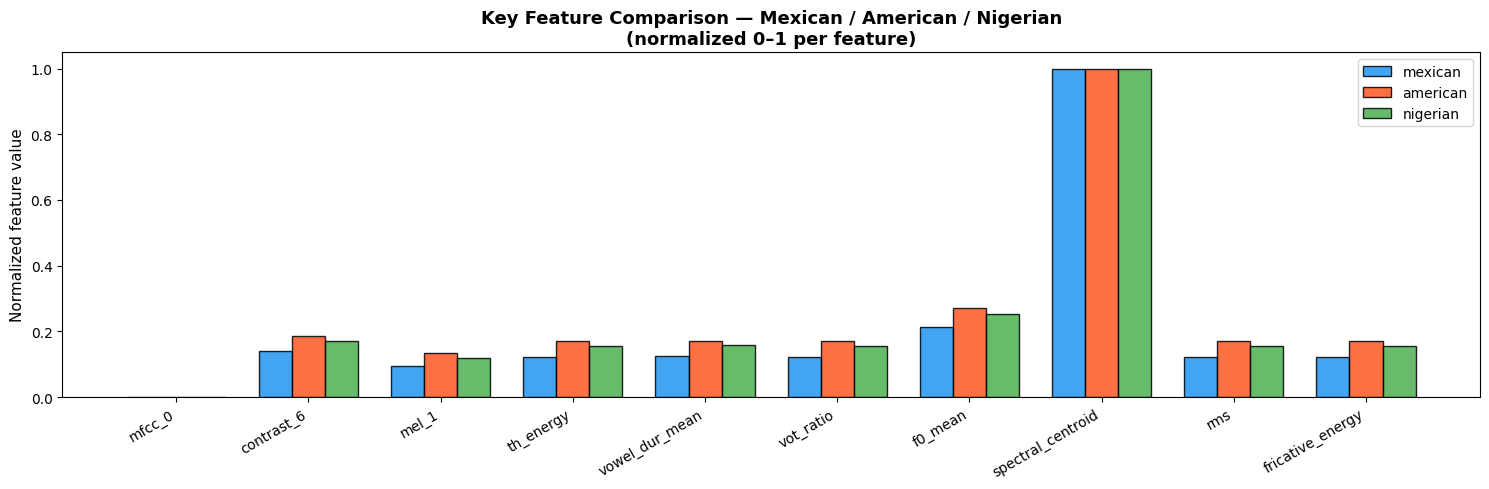

Saved: feature_comparison_3accents.png


In [12]:
# ============================================================
# SECTION 10B: FEATURE COMPARISON ACROSS 3 ACCENTS
# Which features best separate each pair?
# ============================================================

KEY_FEATURES_3 = ['mfcc_0', 'contrast_6', 'mel_1', 'th_energy',
                   'vowel_dur_mean', 'vot_ratio', 'f0_mean',
                   'spectral_centroid', 'rms', 'fricative_energy']

df_3feat = pd.DataFrame(X_3, columns=feature_names)
df_3feat['accent'] = y_3_labels

means_3 = df_3feat.groupby('accent')[KEY_FEATURES_3].mean()

print("\nKey Feature Means — 3 Accents:")
print(means_3.round(4).to_string())

# Radar-style bar comparison for top features
n_feats = len(KEY_FEATURES_3)
x       = np.arange(n_feats)
w       = 0.25
fig, ax = plt.subplots(figsize=(15, 5))

for i, acc in enumerate(THREE_CLASSES):
    vals = means_3.loc[acc, KEY_FEATURES_3].values
    # normalize per feature for visual comparison
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-8)
    ax.bar(x + i*w, norm, w, label=acc, color=color_3[acc],
           edgecolor='black', alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(KEY_FEATURES_3, rotation=30, ha='right')
ax.set_ylabel('Normalized feature value', fontsize=11)
ax.set_title('Key Feature Comparison — Mexican / American / Nigerian\n'
             '(normalized 0–1 per feature)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout()
plt.savefig('feature_comparison_3accents.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: feature_comparison_3accents.png")



Extracting word-level features for 3 accents...
Word-level dataset: 828 segments
  mexican: 290 segments
  american: 306 segments
  nigerian: 232 segments
  Unique words: 10

Words Ranked by Differentiation Power (3 Accents):
   word  total_spread
thought      982.2606
 always      382.7663
     up      315.4127
   when      209.8256
      i      192.8931
      i      192.8931
    was      128.9524
growing      111.9913


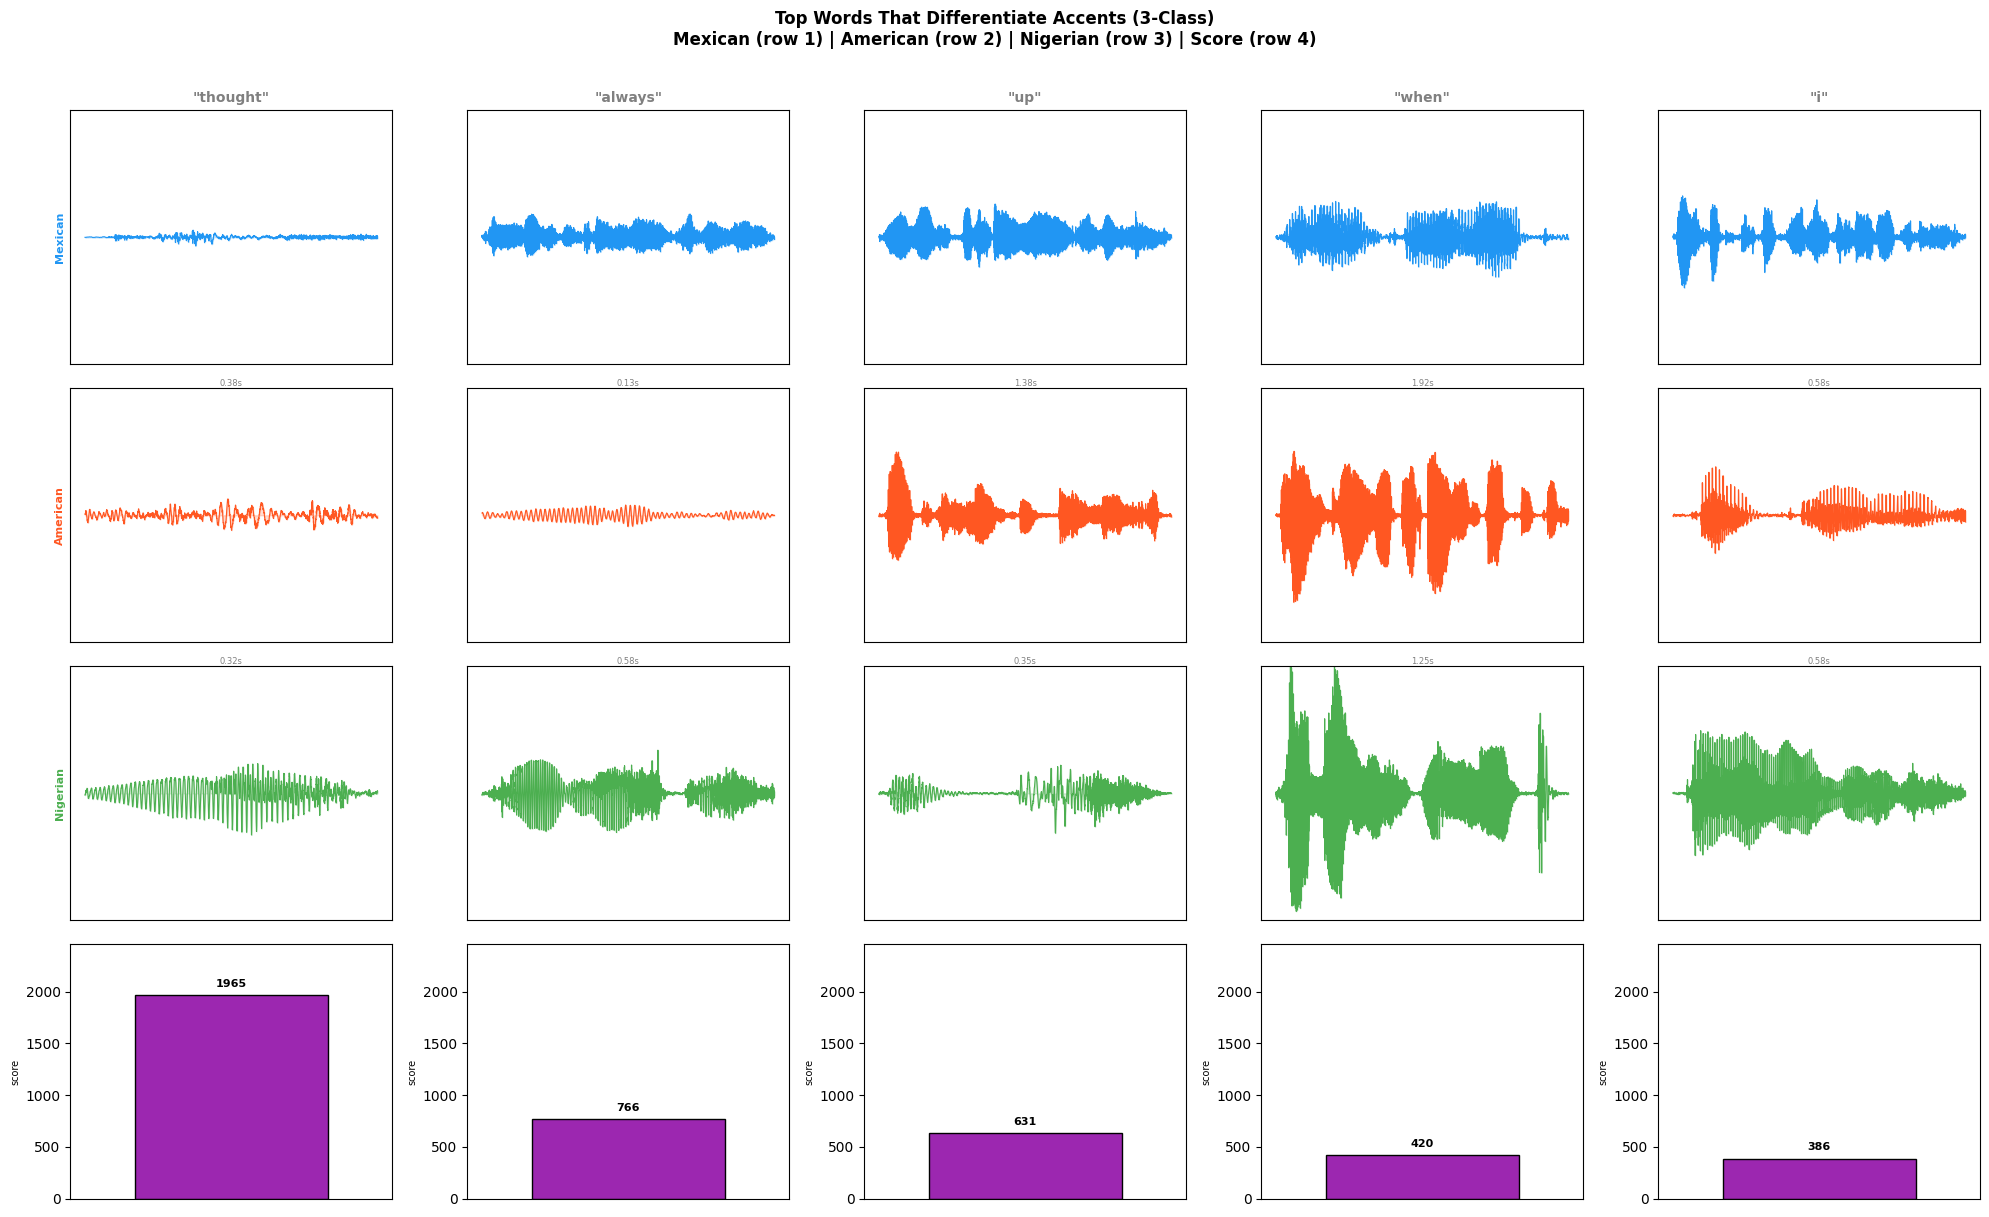

Saved: word_diff_waveforms_3class.png


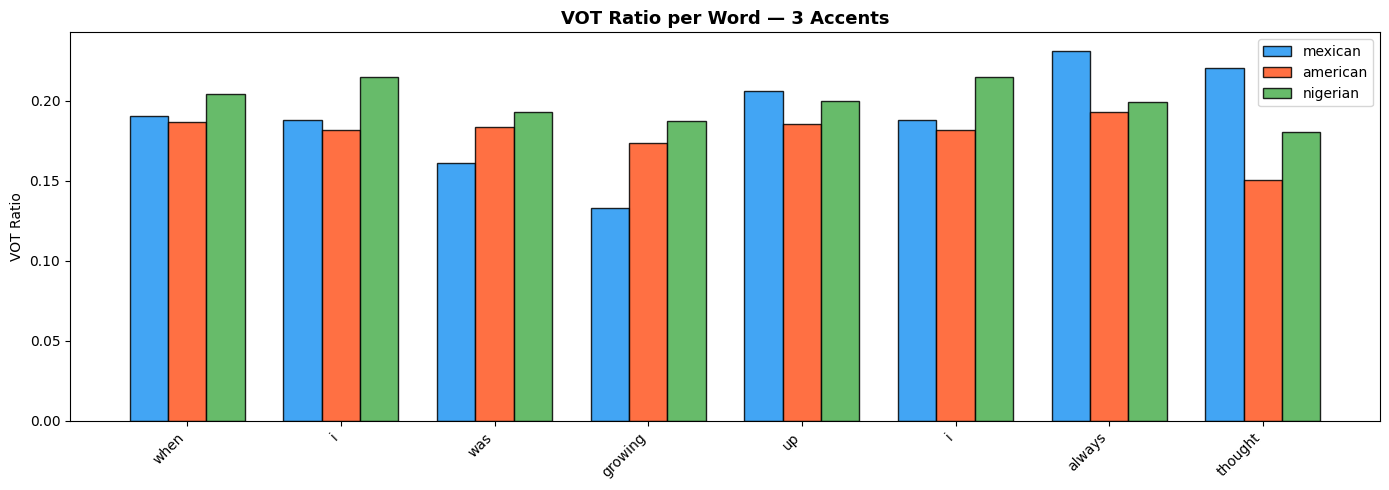

Saved: word_vot_3class.png


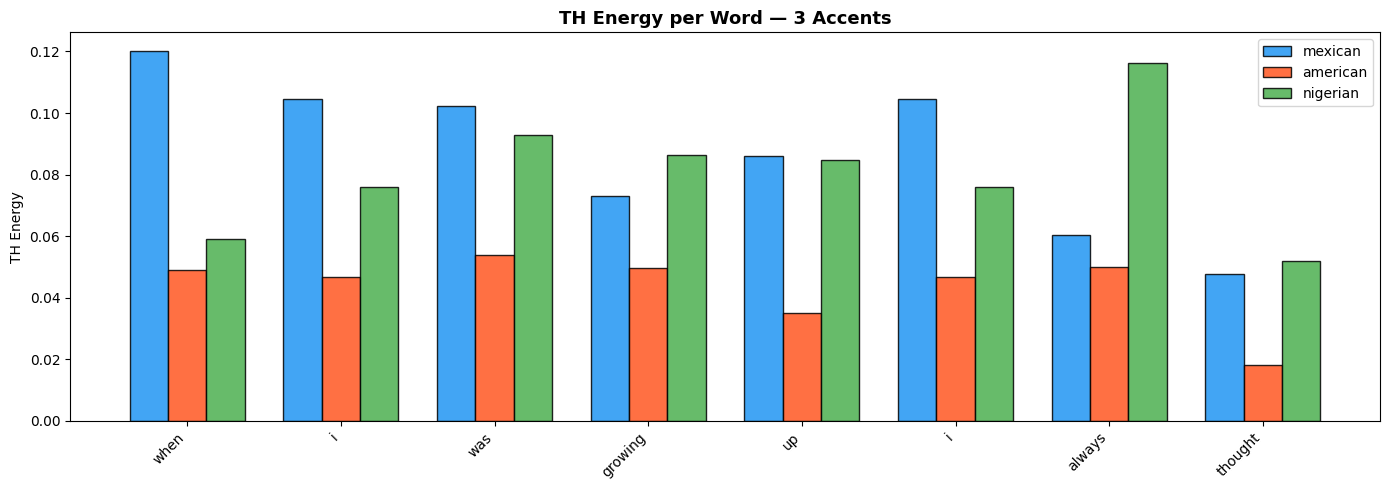

Saved: word_th_3class.png


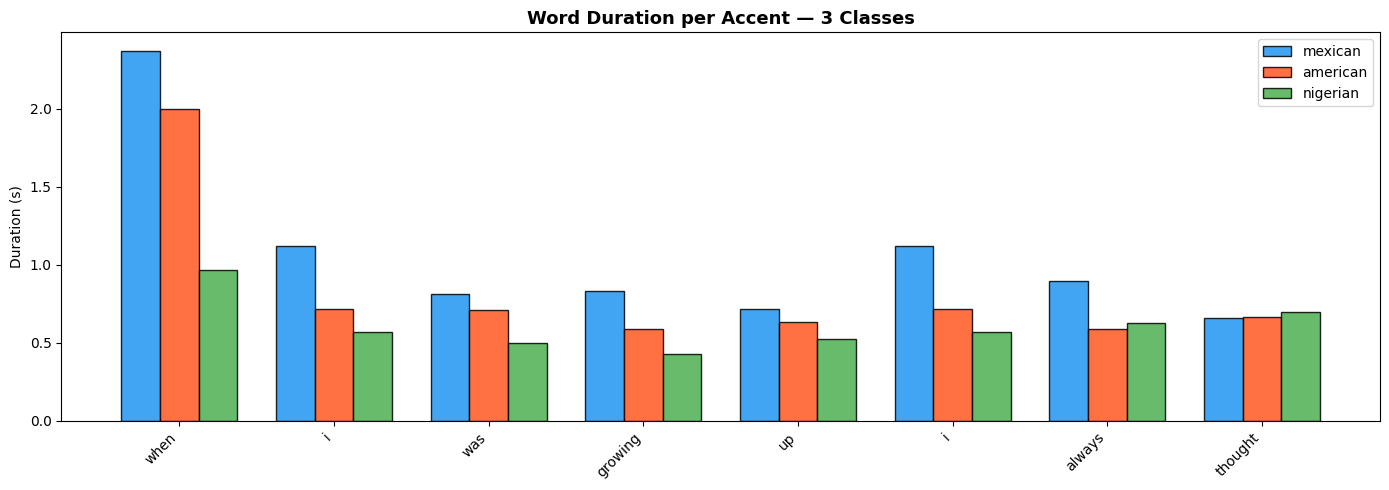

Saved: word_dur_3class.png


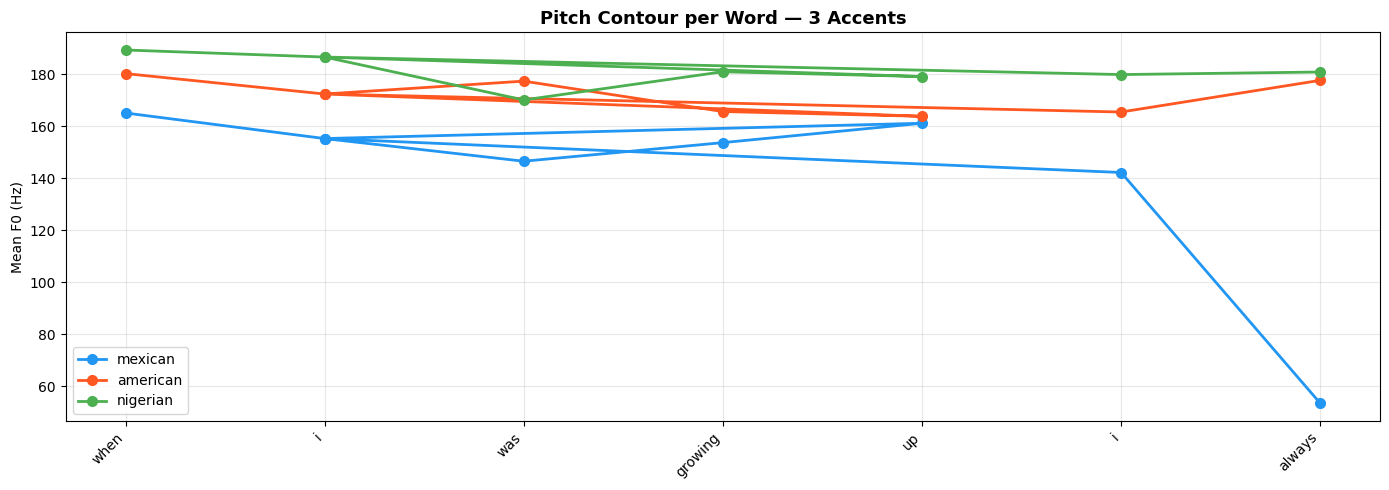

Saved: word_f0_3class.png


In [13]:
# ============================================================
# SECTION 11: WORD-LEVEL ACCENT ANALYSIS (3 ACCENTS)
# ============================================================

SENTENCE_WORDS = [
    "when", "i", "was", "growing", "up", "i", "always",
    "thought", "people", "spoke", "english", "the",
    "same", "way", "everywhere"
]

def extract_segment_features(audio_chunk, sr=16000):
    y = audio_chunk
    if len(y) < 512:
        return None
    feats = {}
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    feats['mfcc_mean'] = np.mean(mfcc, axis=1)
    feats['mfcc_std']  = np.std(mfcc,  axis=1)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=32)
    feats['mel_mean'] = np.mean(librosa.amplitude_to_db(mel, ref=np.max), axis=1)
    stft  = np.abs(librosa.stft(y))
    freqs = librosa.fft_frequencies(sr=sr)
    th_mask = (freqs >= 6000) & (freqs <= 8000)
    feats['th_energy'] = float(np.mean(stft[th_mask, :])) if th_mask.any() else 0.0
    fric_mask = (freqs >= 3000) & (freqs <= 8000)
    feats['fricative_energy'] = float(np.mean(stft[fric_mask, :]) / (np.mean(stft) + 1e-8))
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    ml  = min(len(rms), len(zcr))
    feats['vot_ratio']         = float(np.mean((zcr[:ml] > np.mean(zcr)) & (rms[:ml] < np.mean(rms))))
    feats['spectral_centroid'] = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    feats['duration']          = float(len(y) / sr)
    try:
        snd   = parselmouth.Sound(y.astype(np.float64), sampling_frequency=sr)
        pitch = snd.to_pitch()
        f0    = pitch.selected_array['frequency']
        f0    = f0[f0 != 0]
        feats['f0_mean'] = float(np.mean(f0)) if len(f0) > 0 else 0.0
    except Exception:
        feats['f0_mean'] = 0.0
    return feats


# Build word-level dataset for all 3 accents
print("\nExtracting word-level features for 3 accents...")
word_data = []

for key, ex in examples.items():
    if ex["accent"] not in THREE_CLASSES:
        continue
    segments, _, sr = segment_audio(ex["file_path"])
    for seg_idx, seg in enumerate(segments):
        feats = extract_segment_features(seg['audio'], sr)
        if feats is None:
            continue
        record = {
            'key': key, 'accent': ex["accent"],
            'seg_idx': seg_idx,
            'word': SENTENCE_WORDS[seg_idx]
                    if seg_idx < len(SENTENCE_WORDS)
                    else f'seg_{seg_idx}'
        }
        for fn, fv in feats.items():
            if isinstance(fv, np.ndarray):
                for i, v in enumerate(fv): record[f'{fn}_{i}'] = v
            else: record[fn] = fv
        word_data.append(record)

df_words = pd.DataFrame(word_data)
print(f"Word-level dataset: {len(df_words)} segments")
for acc in THREE_CLASSES:
    print(f"  {acc}: {(df_words['accent']==acc).sum()} segments")
print(f"  Unique words: {df_words['word'].nunique()}")


# Word comparison across 3 accents
KEY_FEATURES_W = ['vot_ratio', 'th_energy', 'fricative_energy',
                   'duration', 'f0_mean', 'spectral_centroid']

word_comparison_3 = []
for word in SENTENCE_WORDS:
    df_word = df_words[df_words['word'] == word]
    subsets = {acc: df_word[df_word['accent'] == acc]
               for acc in THREE_CLASSES}
    if any(len(s) < 2 for s in subsets.values()):
        continue
    row = {'word': word}
    for feat in KEY_FEATURES_W:
        if feat not in df_word.columns: continue
        for acc in THREE_CLASSES:
            row[f'{feat}_{acc}'] = round(subsets[acc][feat].mean(), 4)
        vals = [subsets[acc][feat].mean() for acc in THREE_CLASSES]
        row[f'{feat}_spread'] = round(max(vals) - min(vals), 4)
    word_comparison_3.append(row)

df_comp3 = pd.DataFrame(word_comparison_3)

# Rank by total spread (max - min across 3 accents)
spread_cols = [c for c in df_comp3.columns if c.endswith('_spread')]
df_comp3['total_spread'] = df_comp3[spread_cols].sum(axis=1)
df_ranked3  = df_comp3[['word','total_spread']].sort_values('total_spread', ascending=False)

print("\nWords Ranked by Differentiation Power (3 Accents):")
print(df_ranked3.to_string(index=False))


# ---- Word waveform grid — 3 accents ----
def plot_word_diff_3class(df_words, df_comp3, examples, top_n=5):
    spread_cols = [c for c in df_comp3.columns if c.endswith('_spread')]
    df_c = df_comp3.copy()
    df_c['total_spread'] = df_c[spread_cols].sum(axis=1)
    top_words   = df_c.sort_values('total_spread', ascending=False).head(top_n)['word'].tolist()
    scores_dict = df_c.set_index('word')['total_spread'].to_dict()

    word_audio = {w: {acc: None for acc in THREE_CLASSES} for w in top_words}
    for _, row in df_words.iterrows():
        word = row['word']; acc = row['accent']
        if word not in top_words or acc not in THREE_CLASSES: continue
        if word_audio[word][acc] is not None: continue
        segs, _, sr = segment_audio(examples[row['key']]['file_path'])
        idx = int(row['seg_idx'])
        if idx < len(segs):
            word_audio[word][acc] = {'audio': segs[idx]['audio'], 'sr': sr}

    n    = len(top_words)
    nrow = len(THREE_CLASSES) + 1   # 3 waveform rows + 1 score row
    fig, axes = plt.subplots(nrow, n, figsize=(4*n, 3*nrow))
    if n == 1: axes = axes.reshape(nrow, 1)

    fig.suptitle(
        'Top Words That Differentiate Accents (3-Class)\n'
        'Mexican (row 1) | American (row 2) | Nigerian (row 3) | Score (row 4)',
        fontsize=12, fontweight='bold', y=1.01)

    for col, word in enumerate(top_words):
        for row_idx, acc in enumerate(THREE_CLASSES):
            ax    = axes[row_idx][col]
            data  = word_audio[word][acc]
            color = color_3[acc]
            if data is not None:
                y_a = data['audio']; sr_ = data['sr']
                t   = np.linspace(0, len(y_a)/sr_, len(y_a))
                ax.plot(t, y_a, color=color, linewidth=0.8)
                ax.fill_between(t, y_a, alpha=0.2, color=color)
                ax.set_ylim(-1, 1)
                ax.set_title(f'{len(y_a)/sr_:.2f}s', fontsize=6, color='gray', pad=1)
            else:
                ax.text(0.5, 0.5, 'no sample', ha='center', va='center',
                        transform=ax.transAxes, fontsize=7, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(acc.capitalize(), fontsize=8,
                              color=color, fontweight='bold')
            if row_idx == 0:
                ax.set_title(f'"{word}"', fontsize=10, fontweight='bold')

        # Score bar
        ax_bar    = axes[len(THREE_CLASSES)][col]
        score     = scores_dict.get(word, 0)
        max_score = max(scores_dict.values()) if scores_dict else 1
        ax_bar.bar([0], [score], color='#9C27B0', edgecolor='black', width=0.6)
        ax_bar.set_xlim(-0.5, 0.5); ax_bar.set_ylim(0, max_score*1.25)
        ax_bar.set_xticks([]); ax_bar.set_ylabel('score', fontsize=7)
        ax_bar.text(0, score + max_score*0.04, f'{score:.0f}',
                    ha='center', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.savefig('word_diff_waveforms_3class.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: word_diff_waveforms_3class.png")

plot_word_diff_3class(df_words, df_comp3, examples, top_n=5)


# ---- VOT and TH energy per word — 3 accents ----
words_in_data = df_comp3['word'].tolist()
x = np.arange(len(words_in_data)); w = 0.25

for feat, ylabel_str, title_str, fname in [
    ('vot_ratio',   'VOT Ratio',    'VOT Ratio per Word — 3 Accents',       'word_vot_3class.png'),
    ('th_energy',   'TH Energy',    'TH Energy per Word — 3 Accents',       'word_th_3class.png'),
    ('duration',    'Duration (s)', 'Word Duration per Accent — 3 Classes', 'word_dur_3class.png'),
    ('f0_mean',     'Mean F0 (Hz)', 'Pitch Contour per Word — 3 Accents',   'word_f0_3class.png'),
]:
    fig, ax = plt.subplots(figsize=(14, 5))
    for i, acc in enumerate(THREE_CLASSES):
        col_name = f'{feat}_{acc}'
        if col_name not in df_comp3.columns: continue
        vals = df_comp3[col_name].values
        if feat == 'f0_mean':
            ax.plot(words_in_data, vals, 'o-', color=color_3[acc],
                    linewidth=2, markersize=7, label=acc)
        else:
            ax.bar(x + i*w, vals, w, label=acc,
                   color=color_3[acc], edgecolor='black', alpha=0.85)
    if feat != 'f0_mean':
        ax.set_xticks(x + w)
    ax.set_xticklabels(words_in_data, rotation=45, ha='right')
    ax.set_title(title_str, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel_str); ax.legend(fontsize=10)
    if feat == 'f0_mean':
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


SECTION 12: MODEL ERROR ANALYSIS (3-CLASS)

Best model        : LR (82.1%)
Test set size     : 56
Correct           : 46
Misclassified     : 10

Error breakdown:
  True Accent     Predicted As    Count
  american        mexican         6
  american        nigerian        1
  mexican         american        3


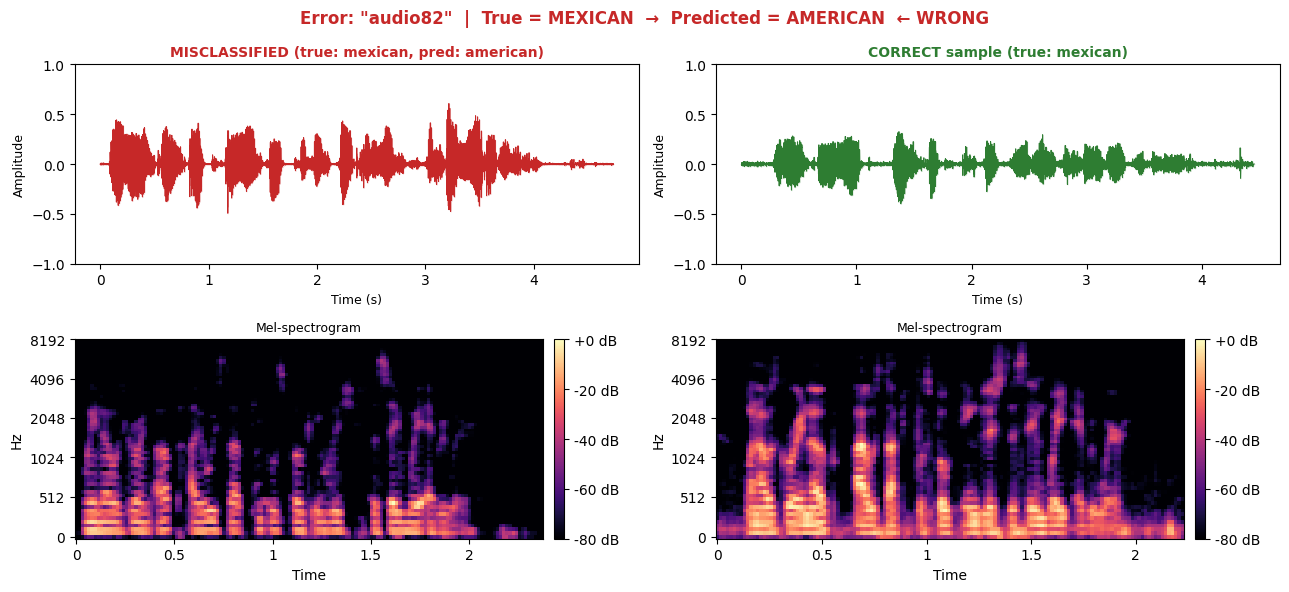

Saved: error_3class_audio82.png


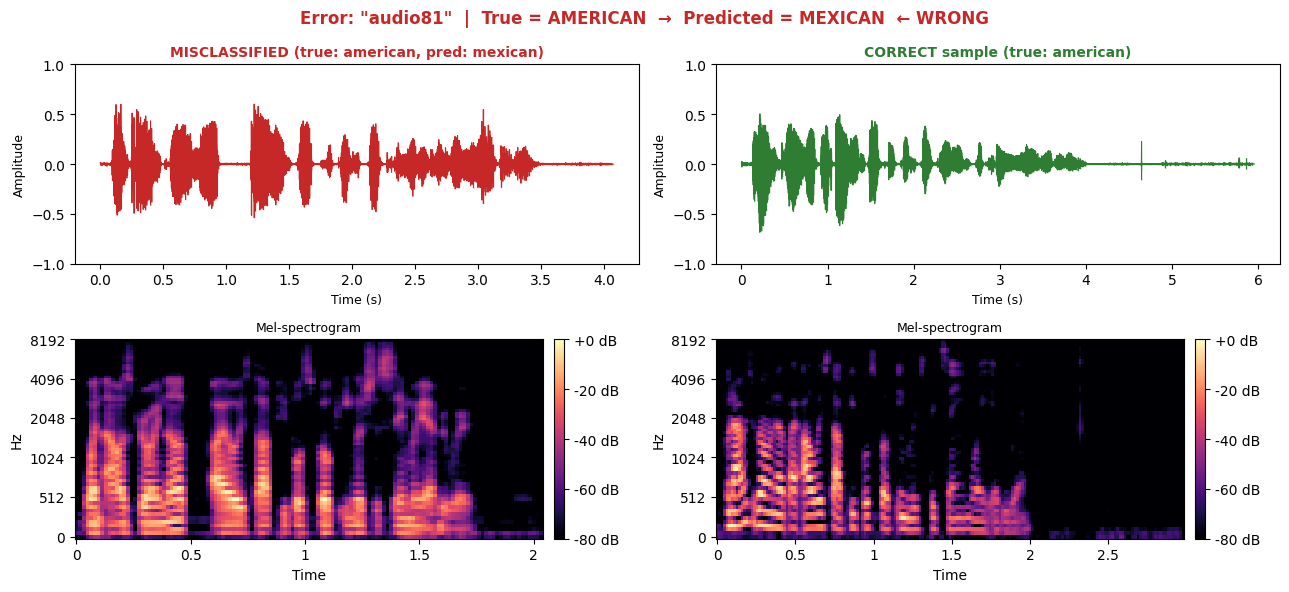

Saved: error_3class_audio81.png


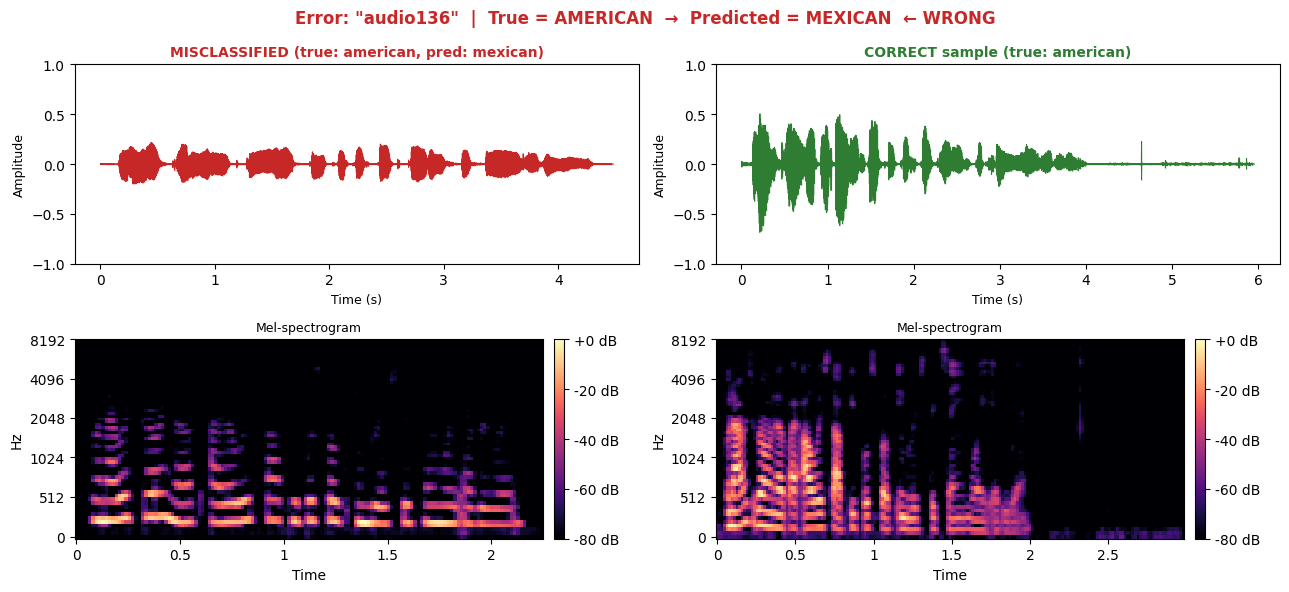

Saved: error_3class_audio136.png


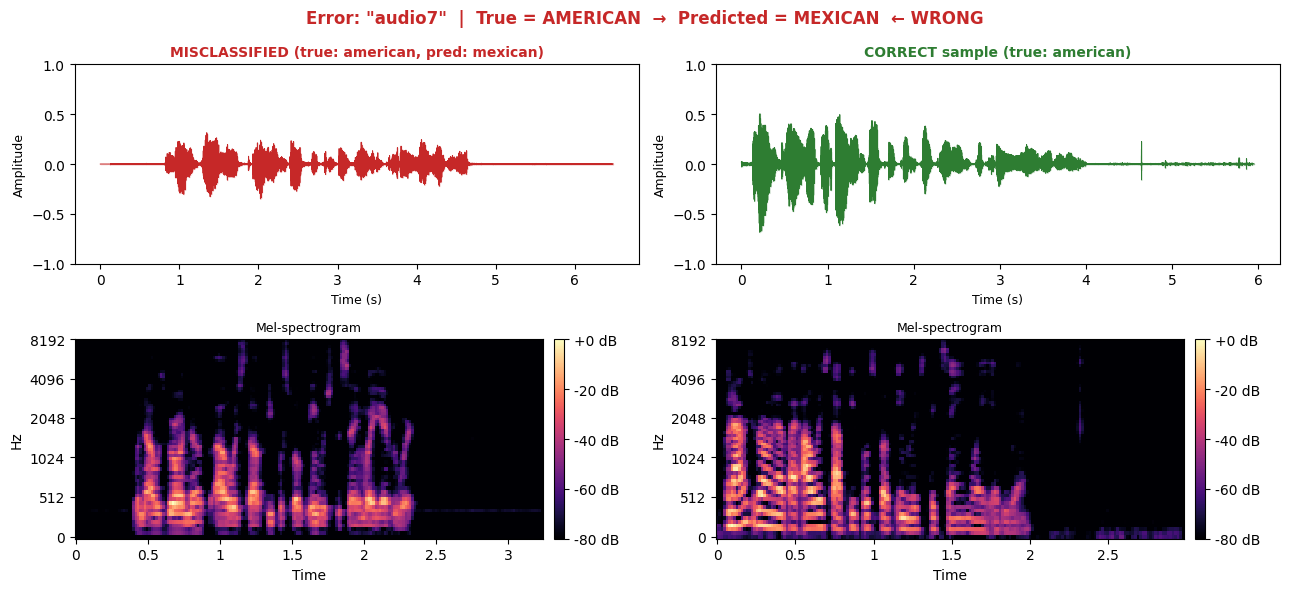

Saved: error_3class_audio7.png

12c. Feature-level explanation:

  audio82 | True: MEXICAN → Predicted: AMERICAN
  Feature                    Sample  Mean(mexican) Mean(american)  Closer to
  --------------------------------------------------------------------
  mfcc_0                  -265.6549      -215.7983      -296.0529  american  ← confused here
  contrast_6                25.8356        32.2442        27.0805  american  ← confused here
  th_energy                  0.0236         0.1174         0.0480  american  ← confused here
  vot_ratio                  0.1275         0.1886         0.1748  american  ← confused here
  vowel_dur_mean             0.9920         2.1803         1.6994  american  ← confused here
  f0_mean                  123.9515       159.0120       176.1350  mexican
  rms                        0.0763         0.0769         0.0545  mexican

  audio81 | True: AMERICAN → Predicted: MEXICAN
  Feature                    Sample Mean(american)  Mean(mexican)  Closer t

In [14]:
# ============================================================
# SECTION 12: MODEL ERROR ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("SECTION 12: MODEL ERROR ANALYSIS (3-CLASS)")
print("=" * 60)

# Best model selection
best_name = max(
    [("LR", lr3_acc, ye3_te, lr3_pred),
     ("SVM", svm3_acc, y3_te, svm3_pred),
     ("RF", rf3_acc, y3_te, rf3_pred)],
    key=lambda x: x[1]
)
bname, bacc, btrue, bpred = best_name

true_names = le3.inverse_transform(btrue)
pred_names = le3.inverse_transform(bpred)

# Recover test keys
all_3_keys = [k for k, ex in examples.items() if ex['accent'] in THREE_CLASSES]
all_3_labs = [examples[k]['accent'] for k in all_3_keys]

_, test_keys_3, _, _ = train_test_split(
    all_3_keys, all_3_labs, test_size=0.25,
    random_state=42, stratify=all_3_labs)

errors = [{'key': test_keys_3[i], 'model': bname,
           'file_path': examples[test_keys_3[i]]['file_path'],
           'true': t, 'predicted': p}
          for i, (t, p) in enumerate(zip(true_names, pred_names)) if t != p]

print(f"\nBest model        : {bname} ({bacc*100:.1f}%)")
print(f"Test set size     : {len(btrue)}")
print(f"Correct           : {len(btrue) - len(errors)}")
print(f"Misclassified     : {len(errors)}")

# Error breakdown by true class
err_df = pd.DataFrame(errors)
if not err_df.empty:
    print("\nError breakdown:")
    print(f"  {'True Accent':<15} {'Predicted As':<15} {'Count'}")
    for (t, p), grp in err_df.groupby(['true', 'predicted']):
        print(f"  {t:<15} {p:<15} {len(grp)}")

    # Error waveforms
    def plot_error_3class(error_entry, examples):
        true_acc = error_entry['true']
        pred_acc = error_entry['predicted']
        correct_key = next(
            (k for k, ex in examples.items()
             if ex['accent'] == true_acc and k != error_entry['key']),
            None)

        fig, axes = plt.subplots(2, 2, figsize=(13, 6))
        fig.suptitle(
            f'Error: "{error_entry["key"]}"  |  '
            f'True = {true_acc.upper()}  →  Predicted = {pred_acc.upper()}  ← WRONG',
            fontsize=12, fontweight='bold', color='#C62828')

        for col, (fpath, title, color) in enumerate([
            (error_entry['file_path'],
             f'MISCLASSIFIED (true: {true_acc}, pred: {pred_acc})', '#C62828'),
            (examples[correct_key]['file_path'] if correct_key else None,
             f'CORRECT sample (true: {true_acc})', '#2E7D32'),
        ]):
            if not fpath:
                for r in range(2):
                    axes[r][col].text(0.5, 0.5, 'no sample', ha='center',
                                      va='center', transform=axes[r][col].transAxes,
                                      color='gray')
                continue
            y_audio, sr = librosa.load(fpath, sr=16000)
            t = np.linspace(0, len(y_audio)/sr, len(y_audio))
            axes[0][col].plot(t, y_audio, color=color, linewidth=0.7)
            axes[0][col].fill_between(t, y_audio, alpha=0.15, color=color)
            axes[0][col].set_ylim(-1, 1)
            axes[0][col].set_xlabel('Time (s)', fontsize=9)
            axes[0][col].set_ylabel('Amplitude', fontsize=9)
            axes[0][col].set_title(title, fontsize=10, fontweight='bold', color=color)
            mel    = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=64, fmax=8000)
            mel_db = librosa.amplitude_to_db(mel, ref=np.max)
            img    = librosa.display.specshow(mel_db, sr=sr, hop_length=256,
                                              x_axis='time', y_axis='mel',
                                              fmax=8000, ax=axes[1][col], cmap='magma')
            axes[1][col].set_title('Mel-spectrogram', fontsize=9)
            fig.colorbar(img, ax=axes[1][col], format='%+2.0f dB', pad=0.02)
        plt.tight_layout()
        fname = f"error_3class_{error_entry['key']}.png"
        plt.savefig(fname, dpi=200, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fname}")

    for err in errors[:4]:
        plot_error_3class(err, examples)

    # Feature-level explanation
    print("\n12c. Feature-level explanation:")
    KEY_FEAT_ERR = ['mfcc_0', 'contrast_6', 'th_energy', 'vot_ratio',
                    'vowel_dur_mean', 'f0_mean', 'rms']
    df_fe = pd.DataFrame(X_3, columns=feature_names)
    df_fe['accent'] = y_3_labels
    df_fe['key']    = [k for k, ex in examples.items()
                       if ex['accent'] in THREE_CLASSES]
    cm3 = df_fe.groupby('accent')[KEY_FEAT_ERR].mean()

    for err in errors[:4]:
        k    = err['key']
        true = err['true']
        pred = err['predicted']
        row  = df_fe[df_fe['key'] == k]
        if row.empty: continue
        print(f"\n  {k} | True: {true.upper()} → Predicted: {pred.upper()}")
        print(f"  {'Feature':<20} {'Sample':>12} {'Mean('+true+')':>14} {'Mean('+pred+')':>14}  Closer to")
        print("  " + "-" * 68)
        for feat in KEY_FEAT_ERR:
            if feat not in df_fe.columns: continue
            val    = row[feat].values[0]
            m_true = cm3.loc[true, feat] if true in cm3.index else float('nan')
            m_pred = cm3.loc[pred, feat] if pred in cm3.index else float('nan')
            closer = pred if abs(val-m_pred) < abs(val-m_true) else true
            flag   = "  ← confused here" if closer == pred else ""
            print(f"  {feat:<20} {val:>12.4f} {m_true:>14.4f} {m_pred:>14.4f}  {closer}{flag}")

print("\n" + "=" * 60)
print("ALL SECTIONS COMPLETE")
print("=" * 60)
saved_plots = [
    'accent_distribution.png',
    'feature_importance_3class.png',
    'vot_waveform_comparison_3class.png',
    'sound_comparison_L_sound_always_3class.png',
    'sound_comparison_TH_sound_thought_3class.png',
    'pca_plot_all.png', 'pca_3class_highlight.png',
    'tsne_plot.png', 'vowel_space_3class.png',
    'classifier_comparison_3class.png',
    'confusion_matrices_3class.png',
    'pca_3class.png',
    'pairwise_difficulty.png',
    'feature_comparison_3accents.png',
    'word_diff_waveforms_3class.png',
    'word_vot_3class.png', 'word_th_3class.png',
    'word_dur_3class.png', 'word_f0_3class.png',
]
for p in saved_plots:
    print(f"  {p}")

In [15]:
# ============================================================
# SECTION 13: SAVE TRAINED MODELS FOR UI USE
# ============================================================
# This section saves everything needed to run predictions
# in a UI WITHOUT re-training:
#
#   accent_model_svm.pkl     ← SVM classifier
#   accent_model_lr.pkl      ← Logistic Regression classifier
#   accent_model_rf.pkl      ← Random Forest classifier
#   accent_scaler.pkl        ← StandardScaler (MUST apply before predicting)
#   accent_label_encoder.pkl ← LabelEncoder  (converts numbers back to accent names)
#   accent_feature_names.pkl ← Feature name list (for debugging)
#   model_metadata.json      ← Accuracy scores, class names, date saved
#
# All files saved to Google Drive so they persist between sessions.
# ============================================================

import pickle
import json
from datetime import datetime

SAVE_DIR = Path("/content/drive/MyDrive/senior_project/saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Saving models to:", SAVE_DIR)

# ---- Save classifiers ----
models_to_save = {
    'accent_model_svm': svm3,
    'accent_model_lr':  lr3,
    'accent_model_rf':  rf,
}
for filename, model_obj in models_to_save.items():
    path = SAVE_DIR / f"{filename}.pkl"
    with open(path, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f"  Saved: {filename}.pkl")

# ---- Save scaler ----
with open(SAVE_DIR / 'accent_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("  Saved: accent_scaler.pkl")

# ---- Save label encoder ----
with open(SAVE_DIR / 'accent_label_encoder.pkl', 'wb') as f:
    pickle.dump(le3, f)
print("  Saved: accent_label_encoder.pkl")

# ---- Save feature names ----
with open(SAVE_DIR / 'accent_feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
print("  Saved: accent_feature_names.pkl")

# ---- Save metadata ----
metadata = {
    "saved_at":       datetime.now().isoformat(),
    "classes":        list(le3.classes_),
    "num_features":   len(feature_names),
    "train_size":     len(X3_tr),
    "test_size":      len(X3_te),
    "accuracies": {
        "svm_test":  round(svm3_acc, 4),
        "lr_test":   round(lr3_acc,  4),
        "rf_test":   round(rf3_acc,  4),
    },
    "best_model":     "svm" if svm3_acc >= max(lr3_acc, rf3_acc)
                      else ("lr" if lr3_acc >= rf3_acc else "rf"),
    "feature_names":  feature_names,
    "sentence":       "When I was growing up I always thought people spoke English the same way everywhere.",
    "sample_rate":    16000,
}
with open(SAVE_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("  Saved: model_metadata.json")

print(f"\nAll models saved successfully to:\n  {SAVE_DIR}")
print(f"\nBest model: {metadata['best_model'].upper()} "
      f"({metadata['accuracies'][metadata['best_model']+'_test']*100:.1f}% test accuracy)")
print(f"Classes: {metadata['classes']}")

Saving models to: /content/drive/MyDrive/senior_project/saved_models
  Saved: accent_model_svm.pkl
  Saved: accent_model_lr.pkl
  Saved: accent_model_rf.pkl
  Saved: accent_scaler.pkl
  Saved: accent_label_encoder.pkl
  Saved: accent_feature_names.pkl
  Saved: model_metadata.json

All models saved successfully to:
  /content/drive/MyDrive/senior_project/saved_models

Best model: LR (82.1% test accuracy)
Classes: [np.str_('american'), np.str_('mexican'), np.str_('nigerian')]


In [16]:
# ============================================================
# SECTION 14: LOAD MODELS & RUN A PREDICTION (UI DEMO)
# ============================================================
# This shows exactly how the UI will call the saved models.
# Copy this into your UI code — it works standalone as long
# as the .pkl files exist in Google Drive (or wherever you
# copy them to).
# ============================================================

def load_accent_models(model_dir):
    """
    Load all saved models from disk.
    Returns a dict with everything needed to run predictions.
    """
    model_dir = Path(model_dir)
    with open(model_dir / 'accent_model_svm.pkl', 'rb') as f:
        svm_model = pickle.load(f)
    with open(model_dir / 'accent_model_lr.pkl', 'rb') as f:
        lr_model = pickle.load(f)
    with open(model_dir / 'accent_model_rf.pkl', 'rb') as f:
        rf_model = pickle.load(f)
    with open(model_dir / 'accent_scaler.pkl', 'rb') as f:
        loaded_scaler = pickle.load(f)
    with open(model_dir / 'accent_label_encoder.pkl', 'rb') as f:
        loaded_le = pickle.load(f)
    with open(model_dir / 'accent_feature_names.pkl', 'rb') as f:
        loaded_names = pickle.load(f)
    with open(model_dir / 'model_metadata.json', 'r') as f:
        loaded_meta = json.load(f)

    print(f"Models loaded. Classes: {loaded_meta['classes']}")
    print(f"Best model: {loaded_meta['best_model'].upper()} "
          f"({loaded_meta['accuracies'][loaded_meta['best_model']+'_test']*100:.1f}%)")

    return {
        'svm': svm_model,
        'lr':  lr_model,
        'rf':  rf_model,
        'scaler':  loaded_scaler,
        'encoder': loaded_le,
        'feature_names': loaded_names,
        'metadata': loaded_meta,
    }


def predict_accent(audio_file_path, loaded_models, model_choice='svm'):
    """
    Given a path to a .wav audio file, returns the predicted accent
    and a confidence score for each class.

    Parameters:
        audio_file_path : str — path to .wav file (16kHz recommended)
        loaded_models   : dict from load_accent_models()
        model_choice    : 'svm', 'lr', or 'rf'

    Returns:
        {
          'predicted_accent': 'american',
          'confidence':       0.87,
          'all_probabilities': {'american': 0.87, 'mexican': 0.09, 'nigerian': 0.04},
          'top_differentiating_words': [...],
          'feature_values': {...}
        }
    """
    # Step 1: Extract features (same pipeline as training)
    spec_feats = extract_spectral_features(audio_file_path)
    cons_feats = extract_consonant_features(audio_file_path)
    combined   = {**spec_feats, **cons_feats}
    feature_vec = flatten_features(combined).reshape(1, -1)

    # Step 2: Scale features (CRITICAL — must use the saved scaler)
    feature_vec_scaled = loaded_models['scaler'].transform(feature_vec)

    # Step 3: Predict
    clf = loaded_models[model_choice]
    pred_encoded = clf.predict(feature_vec_scaled)[0]
    pred_accent  = loaded_models['encoder'].inverse_transform([pred_encoded])[0]

    # Step 4: Confidence scores (probability per class)
    if hasattr(clf, 'predict_proba'):
        proba = clf.predict_proba(feature_vec_scaled)[0]
    else:
        # SVC with probability=True supports this — fallback for others
        proba = np.zeros(len(loaded_models['encoder'].classes_))
        proba[pred_encoded] = 1.0

    class_names  = loaded_models['encoder'].classes_
    all_probs    = {cls: round(float(p), 4)
                    for cls, p in zip(class_names, proba)}
    confidence   = float(proba[pred_encoded])

    # Step 5: Extract a few key feature values for UI display
    fn = loaded_models['feature_names']
    fv = flatten_features(combined)
    key_feats = ['mfcc_0', 'contrast_6', 'th_energy', 'vot_ratio',
                 'vowel_dur_mean', 'f0_mean', 'rms']
    feature_display = {}
    for feat in key_feats:
        if feat in fn:
            feature_display[feat] = round(float(fv[fn.index(feat)]), 5)

    return {
        'predicted_accent':   pred_accent,
        'confidence':         round(confidence, 4),
        'all_probabilities':  all_probs,
        'feature_values':     feature_display,
    }


# ---- DEMO: load models and run a test prediction ----
print("\n" + "=" * 55)
print("DEMO: Loading saved models and running test predictions")
print("=" * 55)

loaded = load_accent_models(SAVE_DIR)

# Test on a few examples from the dataset
test_samples = [(k, ex) for k, ex in examples.items()
                if ex['accent'] in THREE_CLASSES][:6]

print(f"\n{'File':<20} {'True':<12} {'Predicted':<12} {'Confidence':<12} {'Correct?'}")
print("-" * 65)

correct = 0
for key, ex in test_samples:
    result = predict_accent(ex['file_path'], loaded, model_choice='svm')
    is_correct = result['predicted_accent'] == ex['accent']
    if is_correct: correct += 1
    print(f"{key:<20} {ex['accent']:<12} "
          f"{result['predicted_accent']:<12} "
          f"{result['confidence']*100:.1f}%{'':>6} "
          f"{'✓' if is_correct else '✗'}")

print(f"\nDemo accuracy on {len(test_samples)} samples: "
      f"{correct}/{len(test_samples)}")

print("\nExample full result for one file:")
result = predict_accent(test_samples[0][1]['file_path'], loaded, model_choice='svm')
print(f"  Predicted accent : {result['predicted_accent']}")
print(f"  Confidence       : {result['confidence']*100:.1f}%")
print(f"  All probabilities:")
for cls, prob in sorted(result['all_probabilities'].items(),
                         key=lambda x: -x[1]):
    bar = '█' * int(prob * 30)
    print(f"    {cls:<12}: {prob*100:5.1f}%  {bar}")
print(f"  Key features:")
for feat, val in result['feature_values'].items():
    print(f"    {feat:<20}: {val}")


DEMO: Loading saved models and running test predictions
Models loaded. Classes: ['american', 'mexican', 'nigerian']
Best model: LR (82.1%)

File                 True         Predicted    Confidence   Correct?
-----------------------------------------------------------------
audio238             mexican      american     69.0%       ✗
audio202             mexican      mexican      88.9%       ✓
audio149             mexican      mexican      92.0%       ✓
audio160             mexican      mexican      87.7%       ✓
audio232             american     american     84.8%       ✓
audio192             mexican      mexican      83.3%       ✓

Demo accuracy on 6 samples: 5/6

Example full result for one file:
  Predicted accent : american
  Confidence       : 69.0%
  All probabilities:
    american    :  69.0%  ████████████████████
    mexican     :  26.1%  ███████
    nigerian    :   4.9%  █
  Key features:
    mfcc_0              : -246.45201
    contrast_6          : 28.10528
    th_energy  

In [17]:
# ============================================================
# SECTION 15: ECAPA EMBEDDING MODEL SAVE (for LR on embeddings)
# ============================================================
# The LR model trained on ECAPA embeddings needs the ECAPA model
# to generate embeddings at inference time.
# ECAPA is already saved to pretrained_model/ by SpeechBrain.
# We just save the LR model trained on those embeddings separately.
# ============================================================

with open(SAVE_DIR / 'accent_model_lr_ecapa.pkl', 'wb') as f:
    pickle.dump(lr3, f)
print("\nSaved: accent_model_lr_ecapa.pkl")
print("Note: To use this model in the UI you also need the ECAPA")
print("      model from speechbrain/spkrec-ecapa-voxceleb")
print("      (already cached in pretrained_model/ on your Drive)")


def predict_accent_ecapa(audio_file_path, loaded_models, ecapa_model):
    """
    Predict using Logistic Regression on ECAPA embeddings.
    Requires the SpeechBrain ECAPA model to be loaded.

    Parameters:
        audio_file_path : str
        loaded_models   : dict from load_accent_models()
        ecapa_model     : EncoderClassifier (loaded SpeechBrain model)
    """
    signal       = ecapa_model.load_audio(audio_file_path)
    emb          = ecapa_model.encode_batch(signal)
    emb_vec      = emb.squeeze().cpu().numpy().reshape(1, -1)

    clf          = loaded_models['lr']
    pred_encoded = clf.predict(emb_vec)[0]
    pred_accent  = loaded_models['encoder'].inverse_transform([pred_encoded])[0]

    proba        = clf.predict_proba(emb_vec)[0]
    class_names  = loaded_models['encoder'].classes_
    all_probs    = {cls: round(float(p), 4)
                    for cls, p in zip(class_names, proba)}
    confidence   = float(proba[pred_encoded])

    return {
        'predicted_accent': pred_accent,
        'confidence':       round(confidence, 4),
        'all_probabilities': all_probs,
        'model_used':        'LogisticRegression on ECAPA embeddings',
    }


print("\n" + "=" * 55)
print("EVERYTHING SAVED. Files in your Drive:")
print("=" * 55)
for f in sorted(SAVE_DIR.glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size_kb:.1f} KB")

print("""
To use in your UI (minimal code needed):
─────────────────────────────────────────
import pickle, json
from pathlib import Path

SAVE_DIR = Path("path/to/saved_models")

# Load once when UI starts
with open(SAVE_DIR / 'accent_model_svm.pkl', 'rb') as f:
    svm = pickle.load(f)
with open(SAVE_DIR / 'accent_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open(SAVE_DIR / 'accent_label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Run on a new audio file
features = extract_features(new_audio_path)   # your pipeline
scaled   = scaler.transform(features)
encoded  = svm.predict(scaled)[0]
accent   = le.inverse_transform([encoded])[0]
probs    = svm.predict_proba(scaled)[0]        # confidence scores
─────────────────────────────────────────
""")


Saved: accent_model_lr_ecapa.pkl
Note: To use this model in the UI you also need the ECAPA
      model from speechbrain/spkrec-ecapa-voxceleb
      (already cached in pretrained_model/ on your Drive)

EVERYTHING SAVED. Files in your Drive:
  accent_feature_names.pkl                 1.2 KB
  accent_label_encoder.pkl                 0.4 KB
  accent_model_lr.pkl                      5.2 KB
  accent_model_lr_ecapa.pkl                5.2 KB
  accent_model_rf.pkl                      940.2 KB
  accent_model_svm.pkl                     131.1 KB
  accent_scaler.pkl                        3.2 KB
  model_metadata.json                      2.2 KB

To use in your UI (minimal code needed):
─────────────────────────────────────────
import pickle, json
from pathlib import Path

SAVE_DIR = Path("path/to/saved_models")

# Load once when UI starts
with open(SAVE_DIR / 'accent_model_svm.pkl', 'rb') as f:
    svm = pickle.load(f)
with open(SAVE_DIR / 'accent_scaler.pkl', 'rb') as f:
    scaler = pickle.l